# mechanism_viewer real-world examples

## Student performance dataset


This notebook evaluates the package's practicability in real‑world scenarios by applying it to an external dataset. 
The dataset used in this example contains student achievements in the secondary education (high school) of two Portuguese schools: "Gabriel Pereira" and "Mousinho da Silveira" . The main objective of the dataset was to predict the final grade of each student, ``G3``, in both Math and Portuguese courses.

The original files contain student demographic, social, school-support, lifestyle, absence, and grade variables for the two courses. The documentation also states that ``G3`` has a strong correlation with the 1st and 2nd period grades, `G1` and `G2` respectively.

> Note: The dataset has no missing values. Therefore, this notebook creates a controlled missingness copy of the data. The injected missingness is only for testing and demonstration, and it should not be reported as the real missingness of the dataset.

The controlled missingness introduced into the selected variables will be used to test whether the visualization tools can recover the expected missingness patterns.

>Note: `mechanism_viewer` is an exploratory package, and interpretations of its results should always be made with caution.

### 1. Load the dataset

The original dataset is divided in 2 datasets based on the course taken by the students: `student-mat.csv` with all Math students, and `student-por.csv` with the students that take Portuguese course. Both files contain the same set of columns. Therefore, to stack both datasets together, `course` column was added to indicate where each row came from.

> Note: Some students might appear in both course files. For this notebook, this is acceptable because the goal is missing-data mechanism exploration, not to build a fully accurate predictive model.

In [2]:
import pandas as pd

student_mat = pd.read_csv("../sample_data/student/student-mat.csv", sep=";")
student_por = pd.read_csv("../sample_data/student/student-por.csv", sep=";")

student_mat["course"] = "math"
student_por["course"] = "portuguese"

student_df = pd.concat([student_mat, student_por], ignore_index=True)

print("Math dataset shape:", student_mat.shape)
print("Portuguese dataset shape:", student_por.shape)
print("Combined dataset shape:", student_df.shape)

display(student_df.head())

Math dataset shape: (395, 34)
Portuguese dataset shape: (649, 34)
Combined dataset shape: (1044, 34)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,course
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,math
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,math
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,math


The merged dataset has a total of 34 columns, so the injected missingness and respective analysis must be done carefully to avoid missing important patterns.

In addition, the dataset contains a mix of discrete, binary and categorical variables.

### 2. Explore the dataset

First, the code below gives a quick view of the observed distributions.

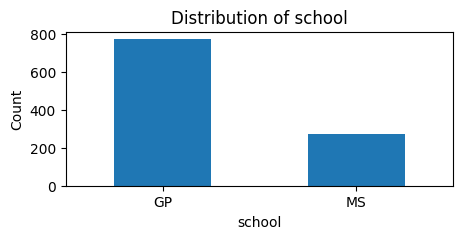

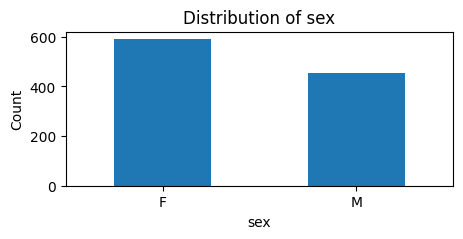

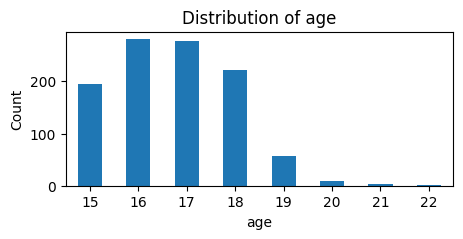

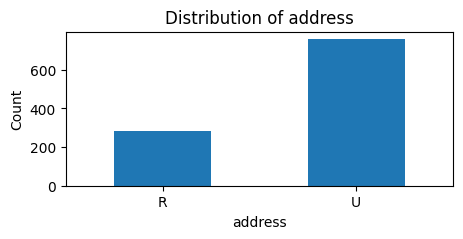

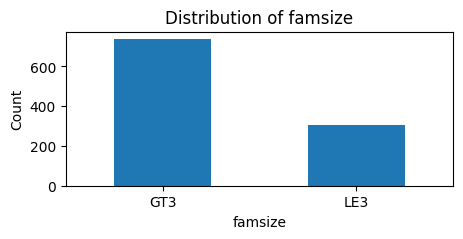

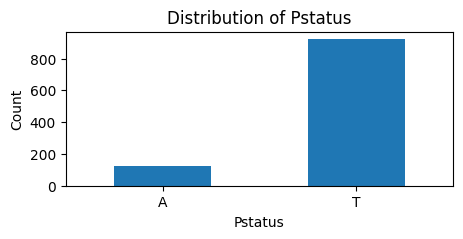

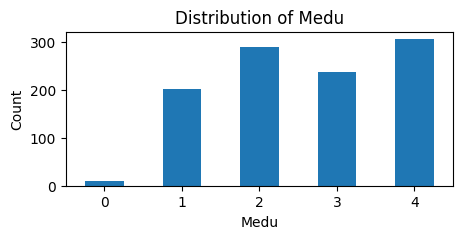

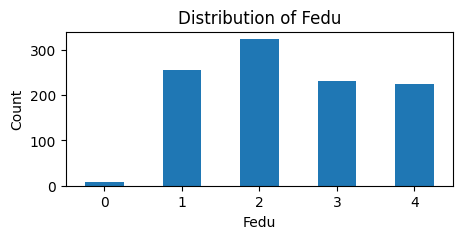

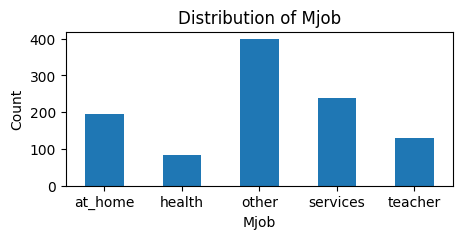

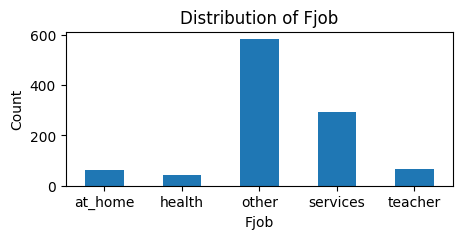

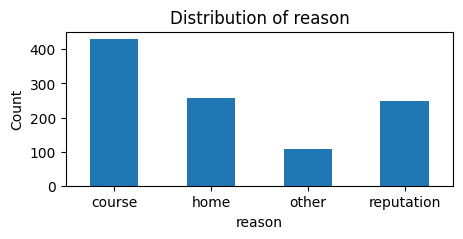

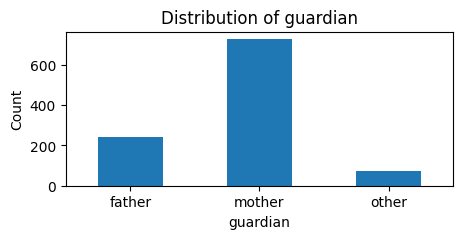

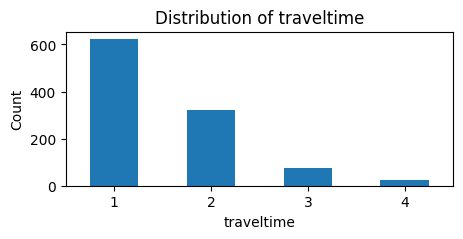

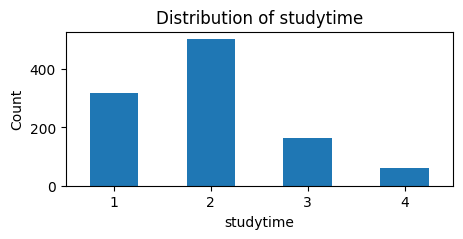

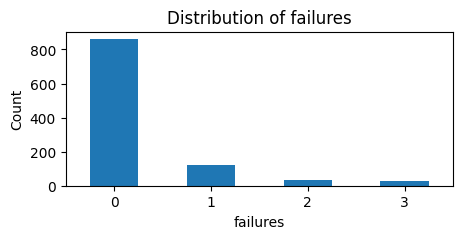

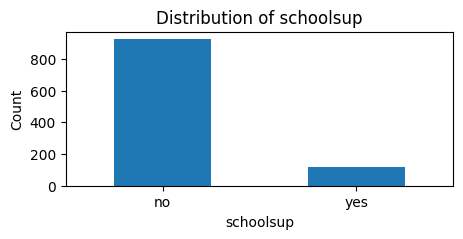

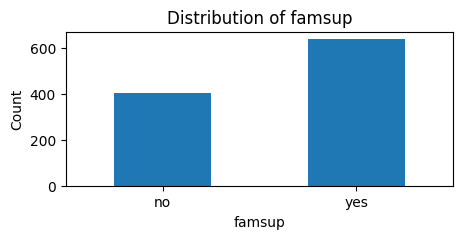

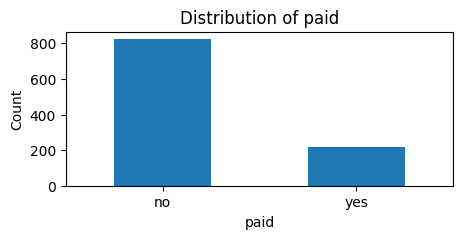

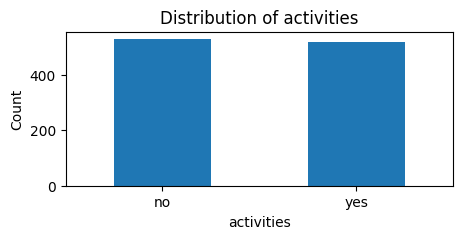

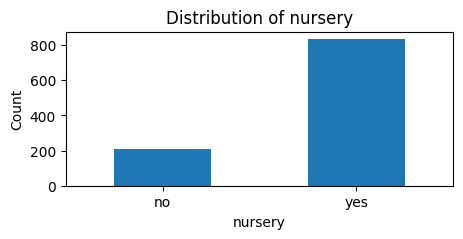

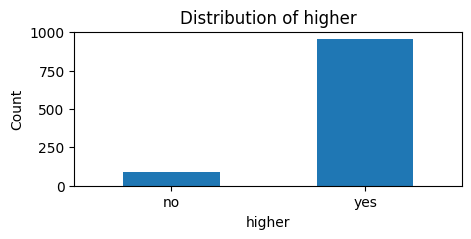

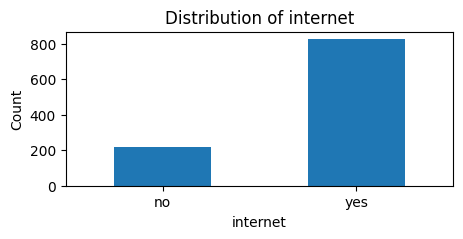

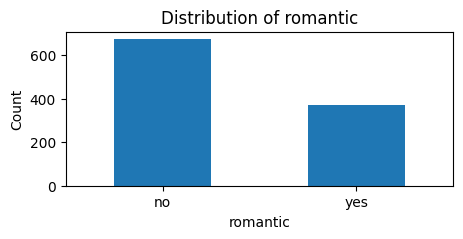

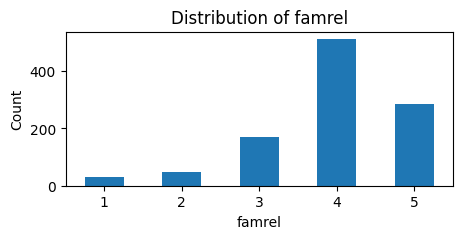

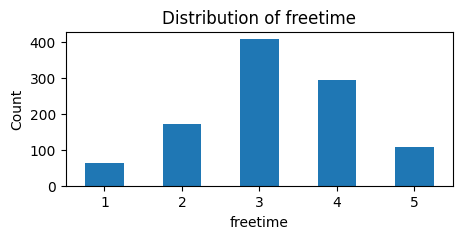

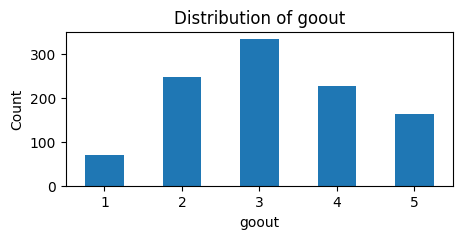

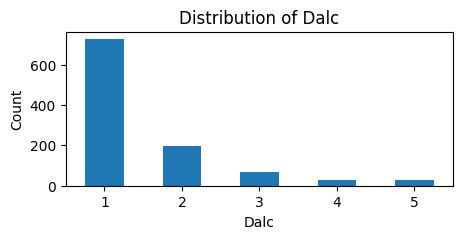

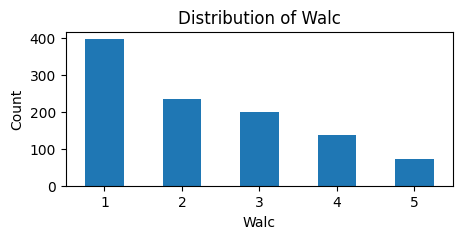

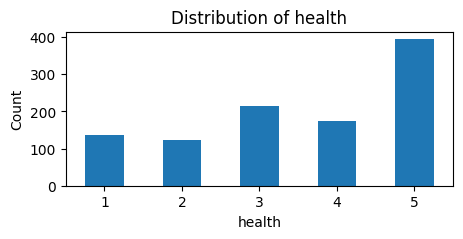

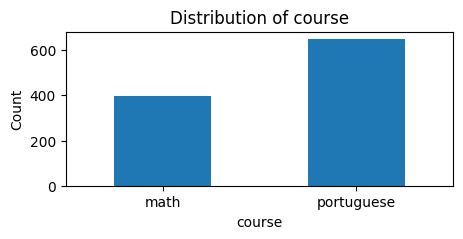

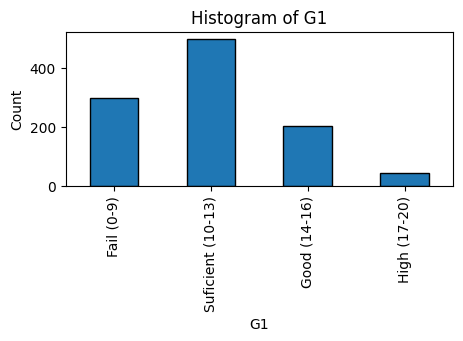

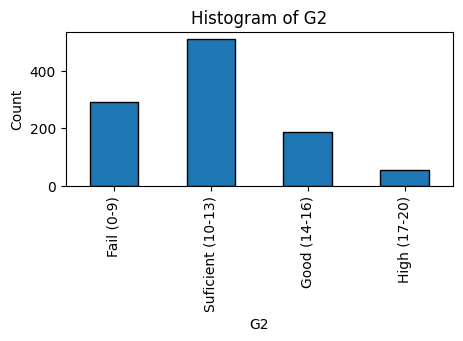

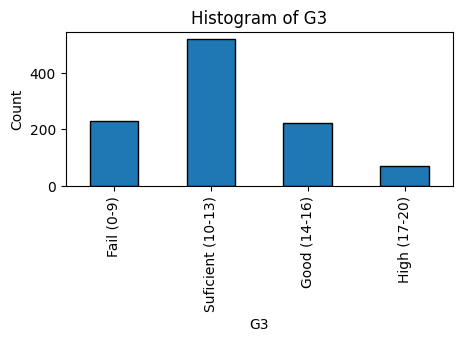

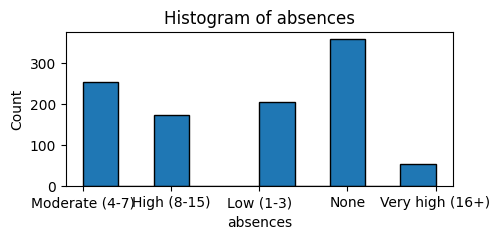

In [3]:
import matplotlib.pyplot as plt

binned_columns = ["absences"]

grade_columns = ["G1", "G2", "G3"]

for discrete_column in student_df.columns :
    if discrete_column not in binned_columns + grade_columns:
        student_df[discrete_column].value_counts().sort_index().plot(kind="bar", figsize=(5, 2), title=f"Distribution of {discrete_column}")
        plt.xlabel(discrete_column)
        plt.ylabel("Count")
        plt.xticks(rotation=0)
        plt.show()

for column in grade_columns:
    col_binned = pd.cut(student_df[column], bins=[-1, 9, 13, 16, 20], labels=["Fail (0-9)", "Suficient (10-13)", "Good (14-16)", "High (17-20)"])
    col_binned.value_counts().sort_index().plot(kind="bar", figsize=(5, 2), edgecolor="black")
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.show()


absences_binned = pd.cut(student_df["absences"],bins=[-1, 0, 3, 7, 15, student_df["absences"].max()],
                                        labels=["None", "Low (1-3)", "Moderate (4-7)", "High (8-15)", "Very high (16+)"],
                                        include_lowest=True)
plt.figure(figsize=(5, 2))
plt.hist(absences_binned, edgecolor='black')
plt.title(f"Histogram of absences")
plt.xlabel("absences")
plt.ylabel("Count")
plt.show()

The original dataset has no missing values. Since all columns appear to contain meaningful information, there is also no clear variable for which replacing zero values with missing values would be justified. Therefore, the rest of the notebook creates and uses a controlled missing-data version from this real-world dataset.

### 3. Adding missingness to the features

To use the package for missingness pattern detection, the dataset is required to have some missingness.

So, the rest of the notebook uses a **controlled missingness copy** of the data. The missingness applied to the dataset was designed to mimic plausible student recording problems.

The injected mechanisms are the following:

- `paid`: applied with **MCAR**. Some information about paid classes are randomly missing.
- `G1`: applied with **MAR**. First-period grade is more likely missing for records with observed risk indicators: previous failures, extra school support, school, and course.
- `absences`: applied with **MNAR**. Very high absence counts are more likely to be missing.
- `studytime`: applied with **MNAR**. Very low study-time values are more likely to be missing.

> Note: This is only for demonstrating the package usability. It should not be reported as the real missingness of the uploaded dataset.

In [4]:
import numpy as np
from mechanism_viewer import DEFAULT_RANDOM_STATE, apply_mcar, apply_mnar

rng = np.random.default_rng(DEFAULT_RANDOM_STATE)
missing_df = student_df.copy()


In [5]:
def choose_rows_by_score(score, missing_rate, noise=0.05):
    """
    Select row indices with the highest score.

    Parameters
    ----------
    score : pd.Series or array-like
        Score used to rank rows.
    missing_rate : float
        Proportion of rows to select.
    noise : float, default=0.05
        Small jitter added so the selected rows are not perfectly deterministic.

    Returns
    -------
    pd.Index
        Row indices selected for missingness.
    """
    score = pd.Series(score).astype(float)

    if score.max() > score.min():
        scaled = (score - score.min()) / (score.max() - score.min())
    else:
        scaled = pd.Series(np.zeros(len(score)), index=score.index)

    jittered = scaled.fillna(0) + rng.normal(0, noise, size=len(scaled))

    n_missing = int(round(len(score) * missing_rate))

    return jittered.sort_values(ascending=False).head(n_missing).index

In [6]:
# MCAR
missing_df["paid"] = apply_mcar(missing_df["paid"], missing_rate=0.10)

# MAR
g1_mar_risk = (missing_df["failures"].rank(pct=True) * 0.60 + missing_df["schoolsup"].eq("yes").astype(int) * 0.20 
              + missing_df["school"].eq("MS").astype(int) * 0.10 + missing_df["course"].eq("math").astype(int) * 0.10)
g1_missing_idx = choose_rows_by_score(g1_mar_risk, missing_rate=0.18, noise=0.02)
missing_df.loc[g1_missing_idx, "G1"] = np.nan

# MNAR
missing_df["absences"] = apply_mnar(missing_df["absences"], missing_rate=0.12, missingness_ascending=True)
missing_df["studytime"] = apply_mnar(missing_df["studytime"], missing_rate=0.10, missingness_ascending=True)

To confirm if the missingness mechanisms were applied, `plot_missing_rate()` can be used again:

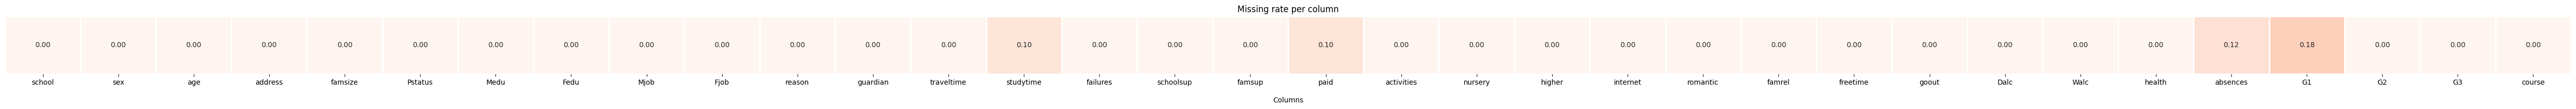

In [7]:
import mechanism_viewer as mv

fig_missing_rate, ax_missing_rate = mv.plot_missing_rate(missing_df, display_plot=True)

As expected, only the four columns (`paid`, `G1`, `absences`, `studytime`) where we intentionally added missingness appear as incomplete.

### 4. Create numeric dataset

After applying the missingness, the dataset still contains some non‑numeric variables.

In [8]:
missing_df.head(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,course
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6.0,NaN,6,6,math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4.0,5.0,5,6,math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10.0,NaN,8,10,math
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2.0,15.0,14,15,math
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4.0,6.0,10,10,math


However, since certain tools require numeric inputs, these variables need to be transformed.

In [9]:
missing_df_numeric = missing_df.copy()

for col in missing_df_numeric.select_dtypes(include=["object", "category"]).columns:
    cat_codes = missing_df_numeric[col].astype("category").cat.codes
    missing_df_numeric[col] = cat_codes.replace(-1, np.nan)

In [10]:
missing_df_numeric.head(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,course
0,0,0,18,1,0,0,4,4,0,4,...,3,4,1,1,3,6.0,NaN,6,6,0
1,0,0,17,1,0,1,1,1,0,2,...,3,3,1,1,3,4.0,5.0,5,6,0
2,0,0,15,1,1,1,1,1,0,2,...,3,2,2,3,3,10.0,NaN,8,10,0
3,0,0,15,1,0,1,4,2,1,3,...,2,2,1,1,5,2.0,15.0,14,15,0
4,0,0,16,1,0,1,3,3,2,2,...,3,2,1,2,5,4.0,6.0,10,10,0


### 5. Rows with similar missing patterns

This plot checks whether missing values appear alone or whether several columns tend to be missing in the same rows.

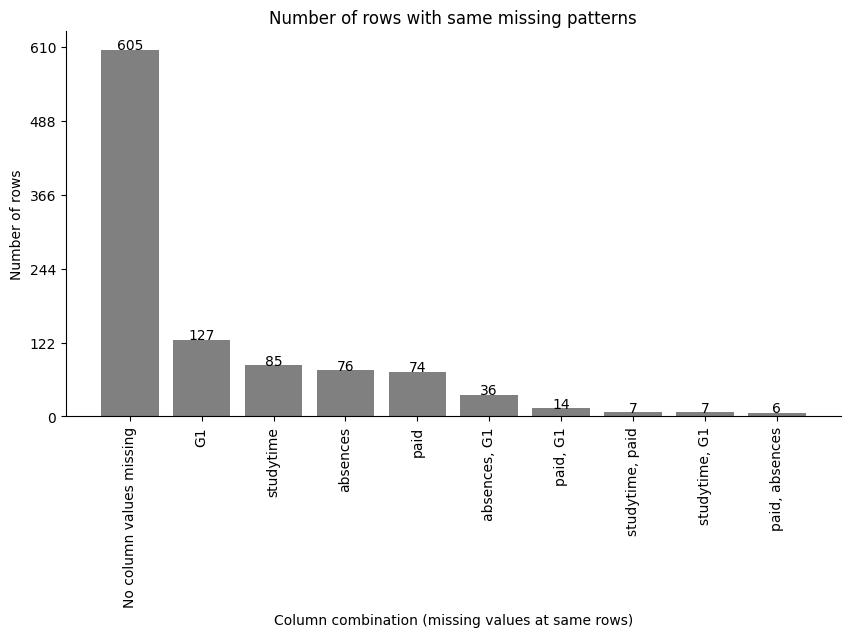

In [11]:
import mechanism_viewer as mv

fig_patterns, ax_patterns = mv.upset_missing_rows(missing_df, min_rows_display=5, display_plot=True)

From the plot, no columns appear to show joint missingness, so it is not possible to infer that any columns share the same missingness pattern.

The only potential comissingness appears between ``absences`` and ``G1``, since the number of rows where both are missing is higher than for any other pair of features. However, this overlap is still smaller than the number of rows missing each feature individually.

### 6. Global MCAR test

To quickly verify the existance of a non-MCAR mechanism in the dataset, a global test using `little_mcar_global()` can be done. 

A global MCAR test should reject the MCAR hypothesis when the data has atleast one missing column with non-MCAR mechanism, provided that the test has enough statistical power.

It is also important to note that this aproach requires all columns to have numeric data.

In [12]:
p_value = mv.little_mcar_global(missing_df_numeric)
print(mv.interpret_mcar_p_value(p_value, alpha=0.05))


Obtained p_value is 0.0.

Interpretation: Reject the null hypothesis. Data is not MCAR (likely MAR or MNAR)


The interpretation provided by the code indicates that the null hypothesis was rejected. Therefore, it is highly likely that there is atleast one non-MCAR missing column in the dataset.

### 7. Missingness correlation between missing columns

The next cell identifies whether the missing indicators are correlated with each other.


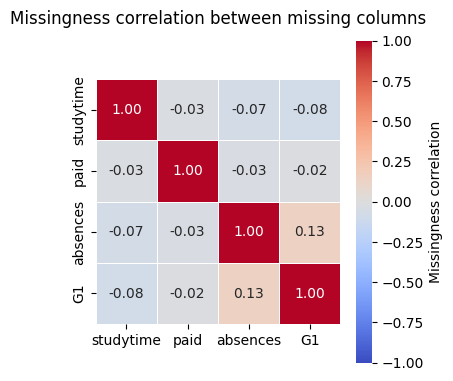

In [13]:
_, _ = mv.missingness_misscol_corr(missing_df, display_plot=True)

Currently, the correlation of the missingness does not indicate any group of columns that have a similar missing pattern, since the values of the heatmap are too weak.

### 8. Correlation between the missingness and the observed values

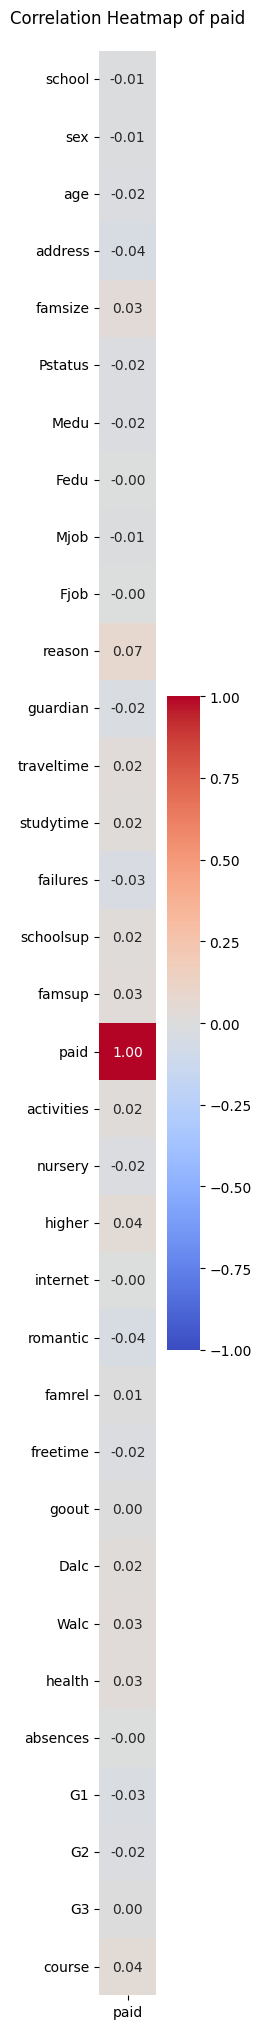

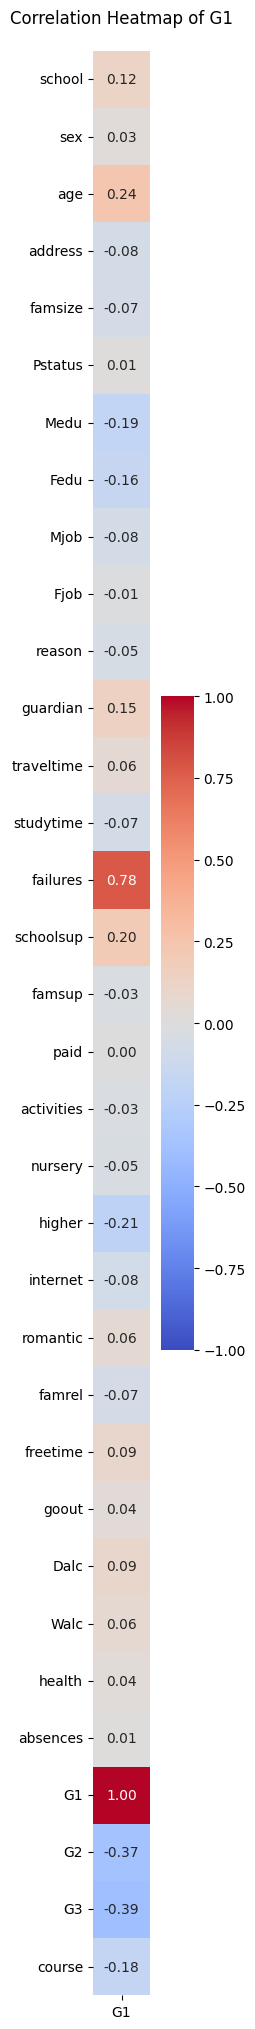

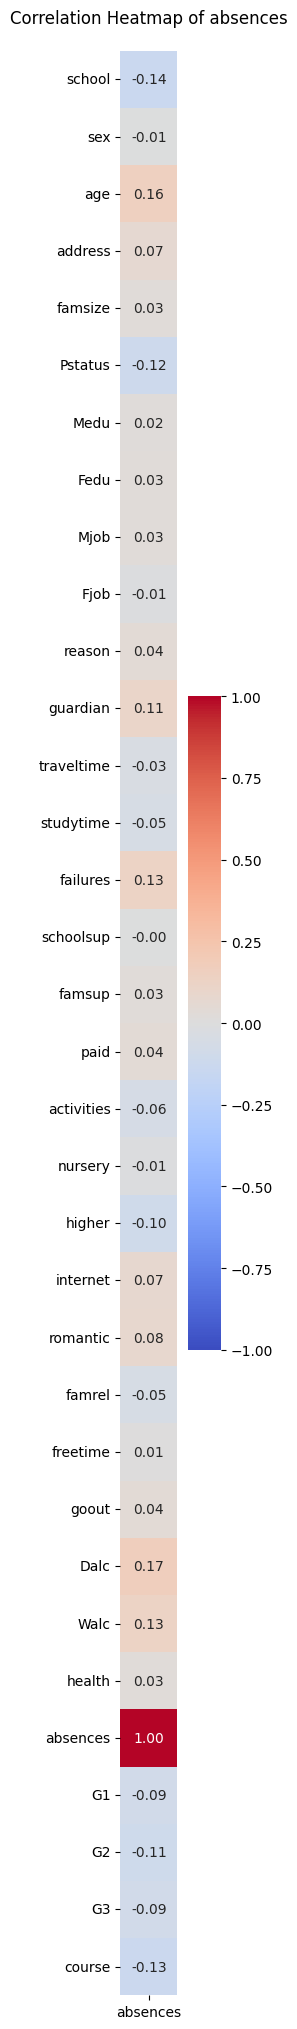

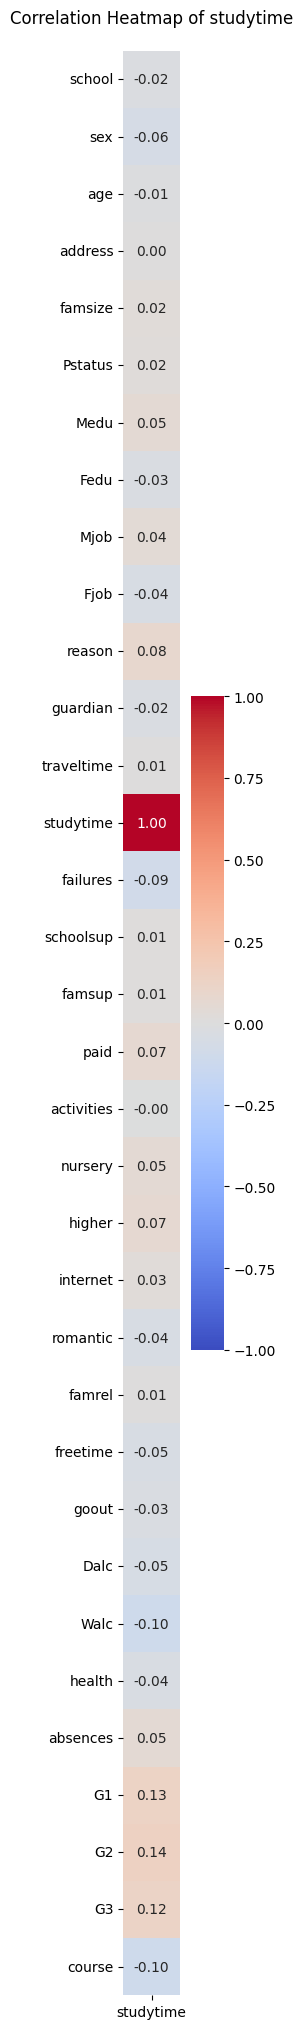

In [14]:
missing_columns = ["paid", "G1", "absences", "studytime"]

for missing_column in missing_columns:
    _, _ = mv.misscol_vs_all_corr(missing_df_numeric, missing_col=missing_column, display_plot=True)

From the resulting heatmaps, the ``paid`` column showed the weakest and the least meaningful correlation between its missingness and any observable variable in the dataset. These low correlations provide some evidence consistent with an MCAR mechanism.

Following that, the heatmap of `studytime` also does not present any strong missingness correlation with the observable variables, although it is not as flat as ``paid``.

The column of `absences` shows a slight increase on the missingness correlation, mainly from `Dalc` (0.17) and `age` (0.16). There are also plenty of columns that show a weak absolute correlation between 0.12 and 0.14, however it is necessary to explore `absences` further to understand whether all these columns affect the missingness of `absences`.

In contrast, `G1` has a strong missingness correlation with `failures` (0.78). Besides, `G2` (-0.37) and `G3` (-0.39) have a moderate correlation with `G1`, but it is known that these variables have a value correlation, so this dependence should be treated carefully. Weaker correlations exist, such as `age` (0.24), `higher` (-0.21), `schoolsup` (0.20), `Medu` (-0.19), `Fedu` (-0.16), `course` (-0.18). It is likely that is missing feature has a MAR missing-data mechanism.
 

### 9. Distribution of observable columns over the missingness of `G1`

To confirm the evidences shown in the previous section about the missingness mechanism of the `G1` column, the distribition of each observable can be plotted against the missingness indicator of the `G1`.

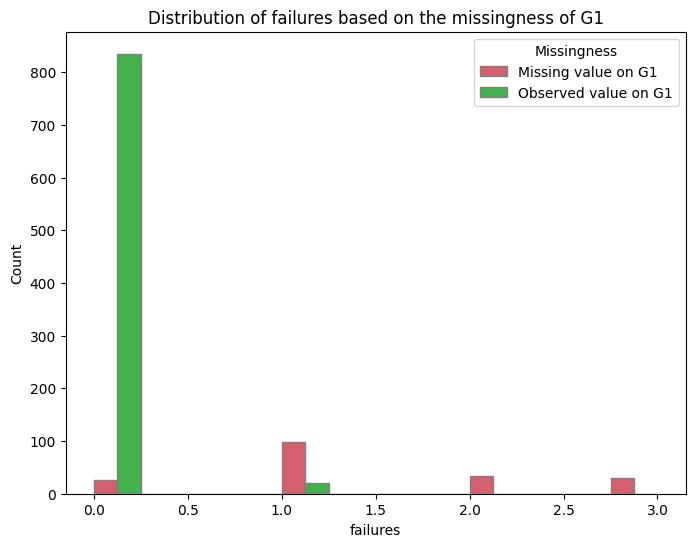

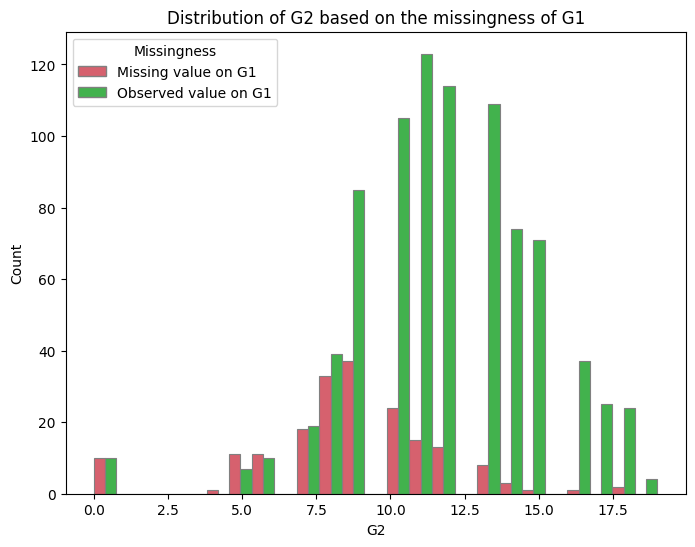

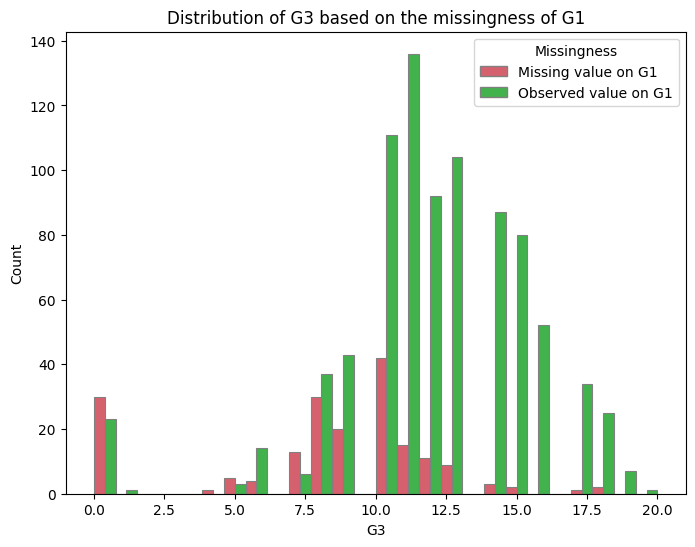

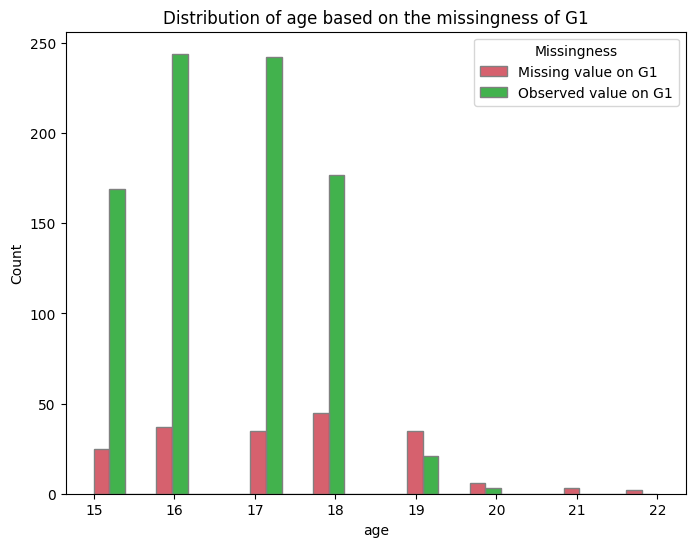

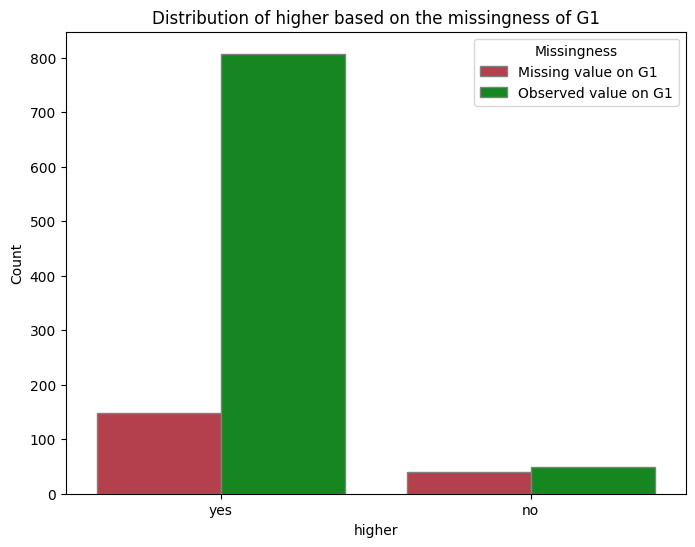

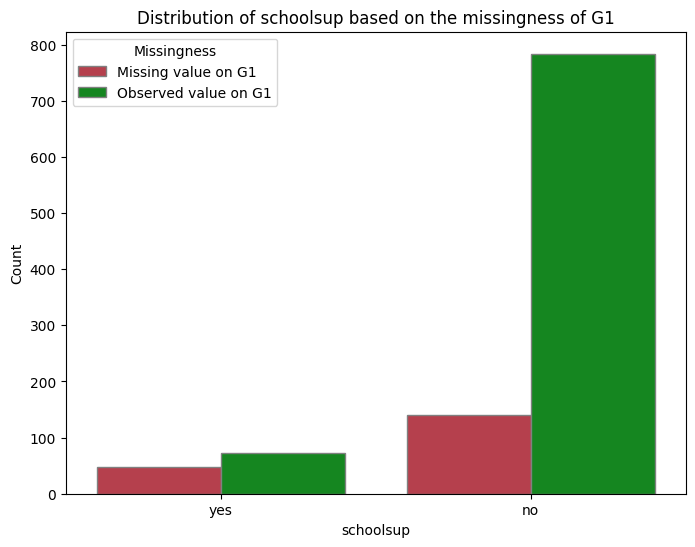

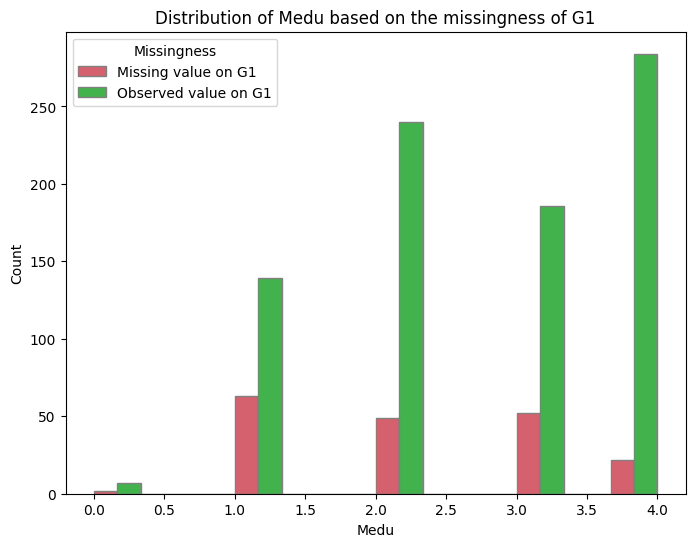

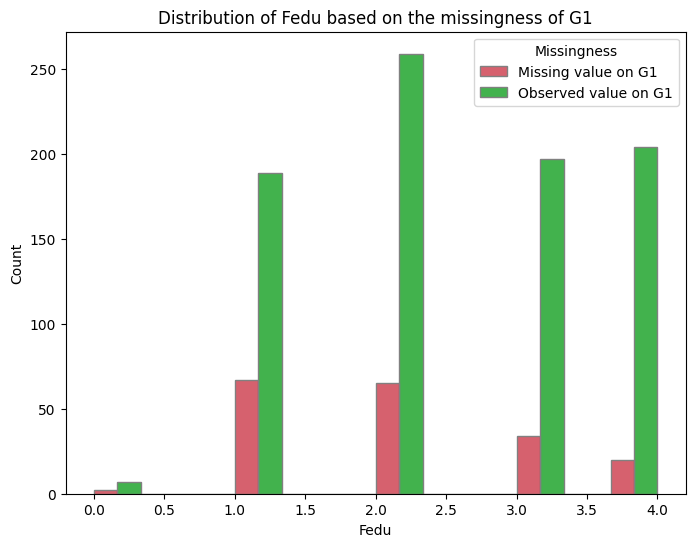

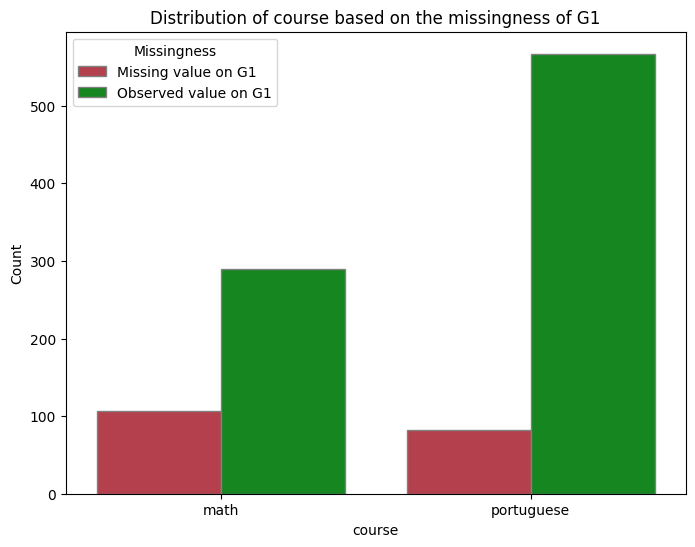

In [15]:
observable_features_G1 = ["G1", "failures", "G2", "G3", "age", "higher", "schoolsup", "Medu", "Fedu", "course"]

_ = mv.plot_missingness_distribution(missing_df[observable_features_G1], missing_col="G1", display_plot=True)

There are some interpretations that can be drawn from these distributions:

- `course`: missing `G1` appears more frequent in math than portuguese. However, the proportions do not look dramatically different. Thus, course may contribute slightly to missingness, but probably not a primary driver.

- `Fedu` and `Medu`: missing `G1` appears relatively more concentrated around lower to mid parental education levels. Thus, ``G1`` may have its missingness partly dependent on family education variables, prooving the MAR behaviour.

- `schoolsup`: students with `schoolsup = yes` have a much larger proportion of missing ``G1`` relative to the bar size. In constrast, 
`schoolsup = no` remains observed with low missing rate of ``G1``. Therefore, it is highly likely that students receiving educational support may have a disproportionate amount of missingness in ``G1``, confirming a strong MAR indicator.

- `higher`: the `higher` distribution looks like a flipped plot of `schoolsup`. Even the exploration distribution in section 2 shows the same mirrored pattern. Therefore, this variable should also be considered when assessing the missingness mechanism of ``G1``.

- `age`: older students show a noticeable pattern of missing ``G1`` values, which suggests that they are more likely to have missing ``G1``, and thus, provide strong evidence for a MAR mechanism.

- `failures`: there is an overwhelming number of students with `failures = 0` compared with those who have one or more failures. While students with higher numbers of failures are more likely to have ``G1`` missing, students with no failures show a very low missingness rate. Consequently, this provides a strong indication that ``G1`` missingness depends on this variable, reflecting a pattern consistent with MAR.

- `G2` and `G3`: the plots clearly show missing G1 clustering around lower performance values. However, `G2` and especially `G3` are future grades relative to `G1`. So although they show predictive power, they may introduce temporal leakage. Consequently, using them to explain `G1` missingness can be problematic.


### 10. Relationship between `G1`, `G2` and ``G3``

To confirm whether `G2` and `G3` should not be used to explain the missingness of `G1`, this section performs some tests for possible introducion of temporal leakage and assess if this leakage actually partcipates in predicting the missing values.

For example, the first code block uses the value correlations of these columns to assess whether the variables are strongly correlated.

In [16]:
missing_df[["G1","G2","G3"]].corr()

,G1,G2,G3
G1,1.000000,0.861875,0.816351
G2,0.861875,1.000000,0.910743
G3,0.816351,0.910743,1.000000


As it is observable, the correlation between `G2` and `G3` is extremely high (0.91). But most importantly, both these variables show also high correlation with `G1`, with 0.86 and 0.81 respectively. Of course, this test alone does not proove the leakage by itself, but it supports the idea that these grades are strongly related sequential measurements.


Next, a heuristic is applied to compute the Accuracy Baseline Difference (ABD). First, the ABD is calculated for ``G1`` as the missing column using the full dataset. Then, the calculation is repeated after removing the ``G2`` and ``G3`` columns to determine whether the accuracy increases or remains unchanged.

In [17]:
# All features used for prediction of G1
abd = mv.test_mar_from_model_accuracy(missing_df_numeric, "G1", print_result=False)
print(abd)

14.19


In [18]:
# G2 and G3 are not used for prediction of G1
abd = mv.test_mar_from_model_accuracy(missing_df_numeric.drop(columns=["G2","G3"]), "G1", print_result=False)
print(abd)

14.35


Calculating the difference gives a result that is pratically negligible (14.35 − 14.19 = 0.16). In other words, removing future grade variables barely changed the ability to predict `G1` missingness. So from the model side, there is little evidence that ``G2`` and ``G3`` are driving the MAR signal.

However, this does not yet prove that there exists temporal leakage. For that,  two imputations are performed: one in which ``G2`` and ``G3`` are removed from the dataset and therefore not used in the imputation of ``G1``, and another in which all variables are included for imputing ``G1``. If ``G2`` and ``G3`` do not introduce temporal leakage, then the imputation process should not produce different results when compared against `G2`.

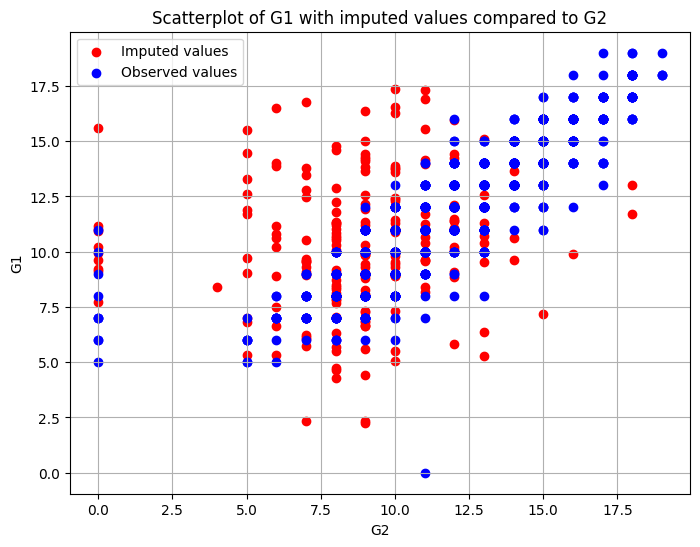

In [19]:
# Imputing G1 without G2 and G3
_, _ , imputed_df = mv.plot_imputation_distribution( missing_df_numeric.drop(columns=["G2","G3"]), "G1")

# Adding G2 after the imputation process is finished for scatterplot comparison
imputed_df["G2"] = missing_df["G2"]

# Scatterplot process similar to the used in the package module
observed_mask = missing_df["G1"].notna()        
imputed_mask = missing_df["G1"].isna() 

fig_imput_comp, ax_imput_comp = plt.subplots(figsize=(8, 6))

ax_imput_comp.scatter(imputed_df.loc[imputed_mask, "G2"], imputed_df.loc[imputed_mask, "G1"],
                      color="red", label="Imputed values")

ax_imput_comp.scatter(missing_df.loc[observed_mask, "G2"], missing_df.loc[observed_mask, "G1"],
                      color="blue", label="Observed values")

ax_imput_comp.set_title("Scatterplot of G1 with imputed values compared to G2")
ax_imput_comp.set_xlabel("G2")
ax_imput_comp.set_ylabel("G1")
ax_imput_comp.grid(True)
ax_imput_comp.legend()
plt.show()

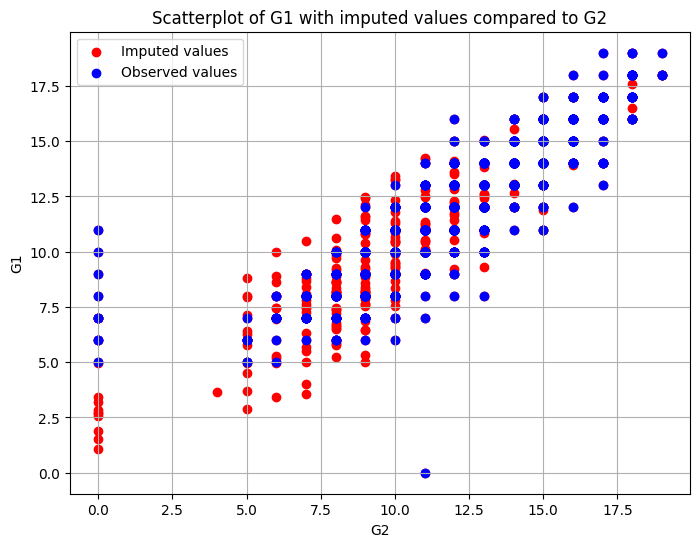

In [20]:
# Imputing G1 with all features, including G2 and G3
_ = mv.scatter_imputation_comparison( missing_df_numeric, "G2", "G1" ,display_plot=True)

The imputation comparison plots reveal that including later grades substantially changes the distribution of imputed ``G1`` values. When ````G2```` and ``G3`` are included, imputed values closely follow the observed ``G1`` and ``G2`` relationship, whereas excluding them produces greater dispersion. This indicates that later grades introduce temporal leakage primarily during imputation rather than during missingness prediction.

Finally, the following code shows that variables with potential temporal leakage do not necessarily contribute to understanding the missingness mechanism of ``G1``. This is done by examining the relationship between the imputed ``G1`` values and ``G2``, using only the rows where ``G1`` was originally missing. Importantly, the imputed dataset used for this calculation was generated without allowing ``G2`` and ``G3`` to participate in the imputation process. Therefore, any remaining relationship reflects information reconstructed from other observed variables rather than direct information leakage from future grades.

In [21]:
# Calculate correlation of G1 using G2
corr_observed = missing_df["G1"].corr(missing_df["G2"])

# Calculate correlation of imputed G1, that were previously missing, using G2
mask = missing_df["G1"].isna()
corr_imputed = (imputed_df.loc[mask, "G1"].corr(missing_df.loc[mask, "G2"]))

print(corr_observed)
print(corr_imputed)


0.8618752328950784
0.09029268813054639


The results show that the rows where ``G1`` was originally missing have almost no relationship with ``G2`` after imputation. In other words, the imputed values do not reconstruct the strong dependency normally observed between ``G1`` and ``G2``. This suggests that ``G2`` contributes very little to the imputed values when it is excluded from the imputation model.

Overall, although ``G2`` and ``G3`` are temporally downstream variables and are theoretically susceptible to temporal leakage, the tests suggest that they do not substantially drive the missingness interpretation of ``G1``. As a result, these variables should be excluded from explaining the missingness mechanism of ``G1``.

### 11. Missing rate matrices

The next matrices will explore the missing rate of each missing column based on the values of observed columns, especifically that may be related to the missingness of `G1`.

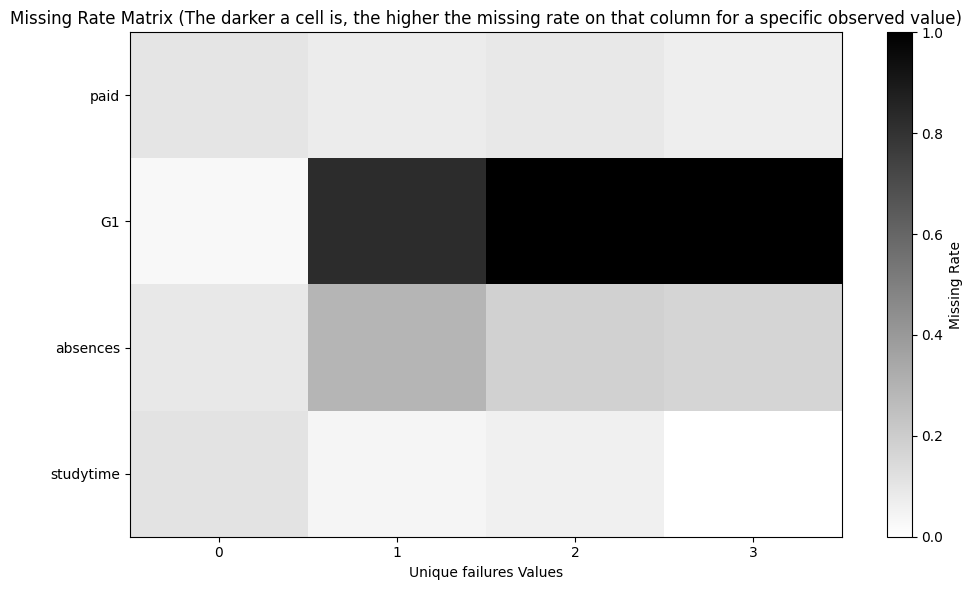

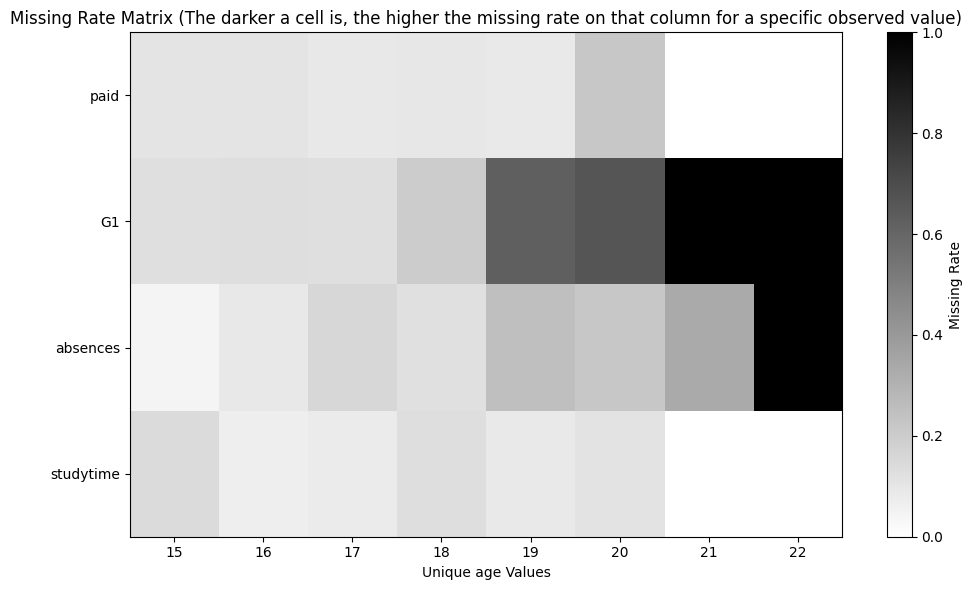

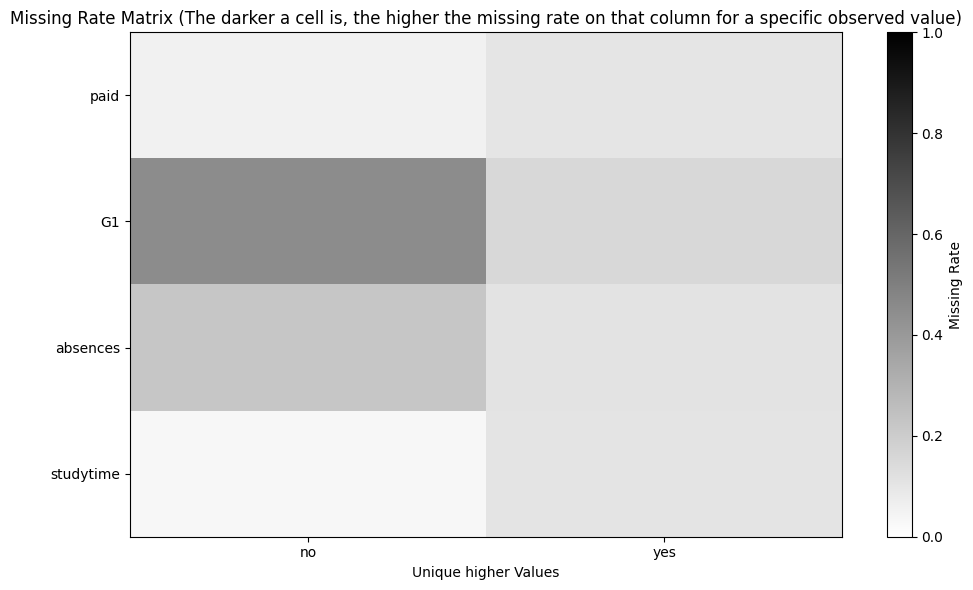

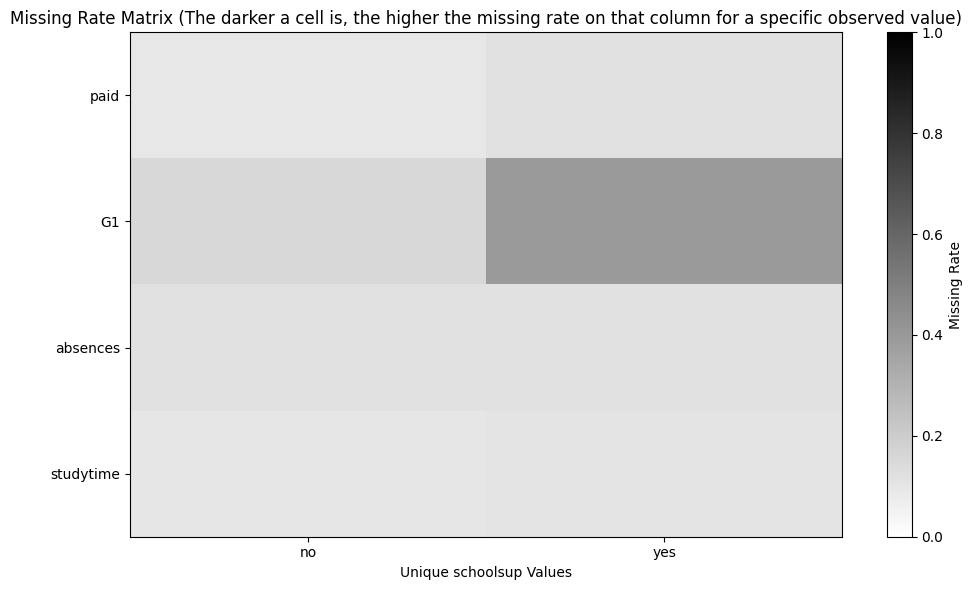

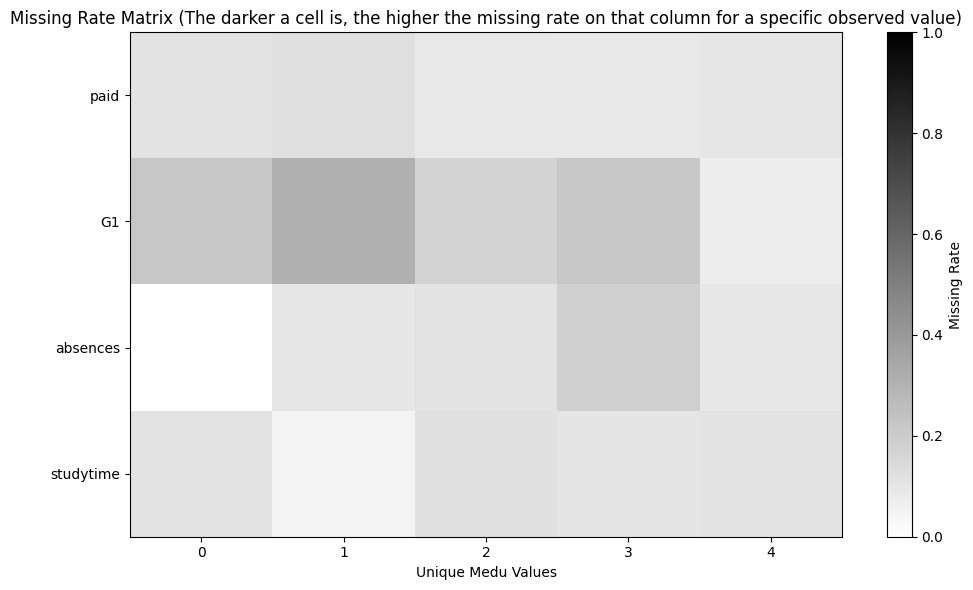

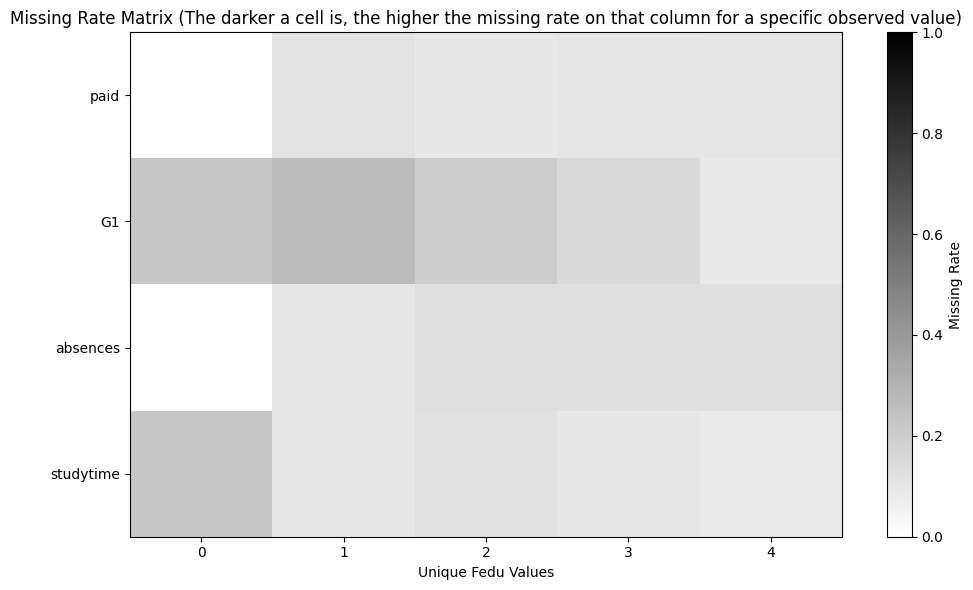

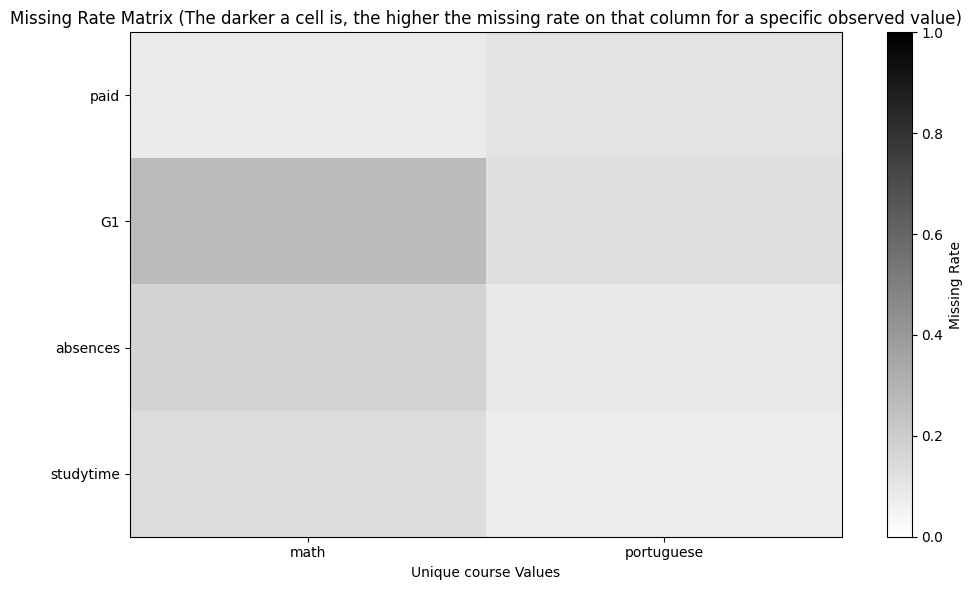

In [22]:
missing_columns = ["paid", "G1", "absences", "studytime"]

observable_features_G1 = ["failures", "age", "higher", "schoolsup", "Medu", "Fedu", "course"]

for observable_column in observable_features_G1:
    mv.missing_rate_matrix(missing_df[missing_columns + [observable_column]], column_name=observable_column, display_plot=True)

These plots suggest following for `G1`:
- `failures`: shows the strongest pattern matrix, since `G1` clearly darkens as failures increase, supporting the MAR mechanism hypothesis.

- `age`: matches the earlier histogram, where older students have an increasing number of missing `G1` values. Therefore, reinforcing a strong MAR evidence.

- ``schoolsup``: most grid cells are light gray, except in the row of `G1` with `schoolsup = yes`, where it is a darker gray, but not as dark as previous features. This feature can support the missingness of `G1`, but does not play the main role for the missingness dependency.

- `higher`: all features show a light gray color when `higher = yes`. However, when `higher = no`, `studytime` and `paid` appear even lighter, whereas `absences` and `G1` are darker, especially `G1`. It is likely that this feature supports the missingness of `G1`.

- `Medu` and `Fedu`: a similar case occur on these features. For education that is not `= 0`, the missing columns have a light gray coloring. For education that is `= 0`, `paid` (only in `Fedu`) and `absences` are lighter, whereas `G1` and `studytime` are darker. Of course, `G1` still shows a weak missing pattern towards lower education, which can support the MAR mechanism.

- `course`: although `G1` is darker for math course, some other missing columns have a similar coloring. This feature might be the weakest pattern for supporting the missing pattern of `G1`.

### 12. Correlation between `G1` observed value and observed features

This heatmap will explore the idea of the observed features having a strong correlation with the available values of `G1`.

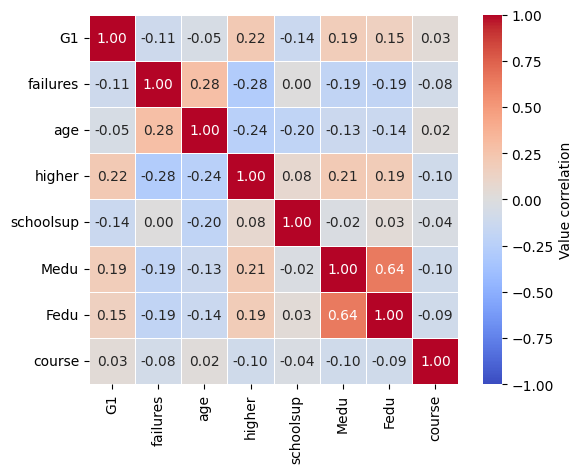

In [23]:
import seaborn as sns

observable_features_G1 = ["G1", "failures", "age", "higher", "schoolsup", "Medu", "Fedu", "course"]

G1_corr = missing_df_numeric[observable_features_G1].corr()

_ = sns.heatmap(G1_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
                square=True, linewidths=0.5, cbar_kws={"label": "Value correlation"})

All observed features have a weak to very weak correlation with the values observed in `G1`, the highest being from `higher` with 0.22. This reinforces the missing MAR patterns present in `G1`.

### 13. MAR test for every missing column

Additionally, the missing columns can each be put under a MAR test. This test checks whether the missingness of one column can be predicted using the observed columns of the dataset, and thus, give some evidence for the possibily that the missing column has a MAR missing-data mechanism. However, it is important to note that a low ABD only indicates that there is a lack of evidence supporting a MAR mechanism.

In [24]:
for missing_column in missing_columns:
    print(f"MAR test for '{missing_column}' missing column:")
    mv.test_mar_from_model_accuracy(missing_df_numeric, missing_column)
    print()

MAR test for 'paid' missing column:
Random Forest Model Accuracy: 0.8854
Logistic Regression Model Accuracy: 0.9013
The target column paid with missing rate of 0.0996 gives an Accuracy Baseline Difference of -0.71.
Since the obtained Accuracy Baseline Difference is -0.71, and the given threshold is 5.0, thus, it is likely that the underlying mechanism of the missing column is MCAR/MNAR.

MAR test for 'G1' missing column:
Random Forest Model Accuracy: 0.9618
Logistic Regression Model Accuracy: 0.9618
The target column G1 with missing rate of 0.1801 gives an Accuracy Baseline Difference of 14.19.
Since the obtained Accuracy Baseline Difference is 14.19, and the given threshold is 5.0, thus, it is likely that the underlying mechanism of the missing column is MAR.

MAR test for 'absences' missing column:
Random Forest Model Accuracy: 0.8822
Logistic Regression Model Accuracy: 0.8726
The target column absences with missing rate of 0.1197 gives an Accuracy Baseline Difference of -0.29.
Since

``G1`` shows the highest Accuracy Baseline Difference (ABD) value, placing it in the range where the missingness mechanism is likely MAR. Knowing the previous results, this is an additional proof for ``G1`` having this mechanism.

In contrast, all other missing columns have ABD values close to zero. This suggests that their missingness cannot be predicted well from the observed variables available in the dataset. Therefore, there is insufficient evidence to classify these columns as MAR, and their underlying mechanism may instead be MCAR or MNAR.

### 14. Missing mechanim of `paid`

To ascertain the missing mechanism of `paid`, it is necessary to review the previous evidences.

- Has a low missing rate, limiting the testing on the feature.
- All observed varaibles indicated little to no relationship between the missingness of the variable.
    - The maximum correlation score for the observed variables were `reason` (0.07), `higher` (0.04), and `course` (0.04).
- Test cannot identify with certainty that feature has missingness predictable with observed variables.

As a consequence, it is unlikely that `paid` has a MAR missing-data mechanism. However, extra tests can be done to confirm it, focusing on the missingness dependency towards the observable features that had the highest correlation with the missing feature.

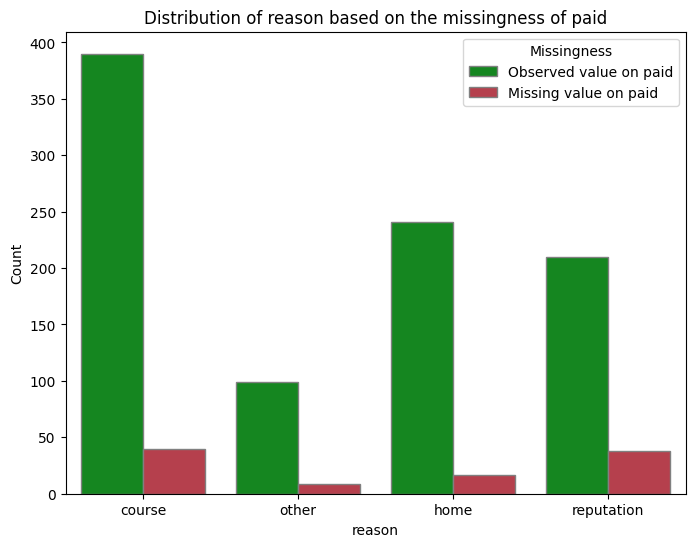

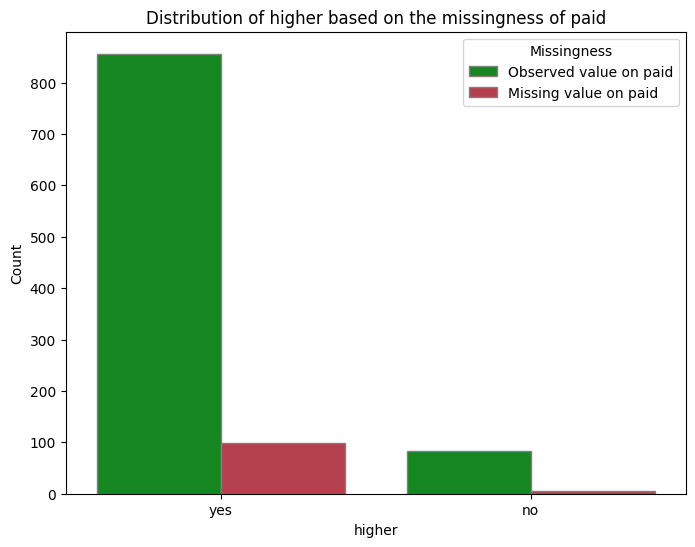

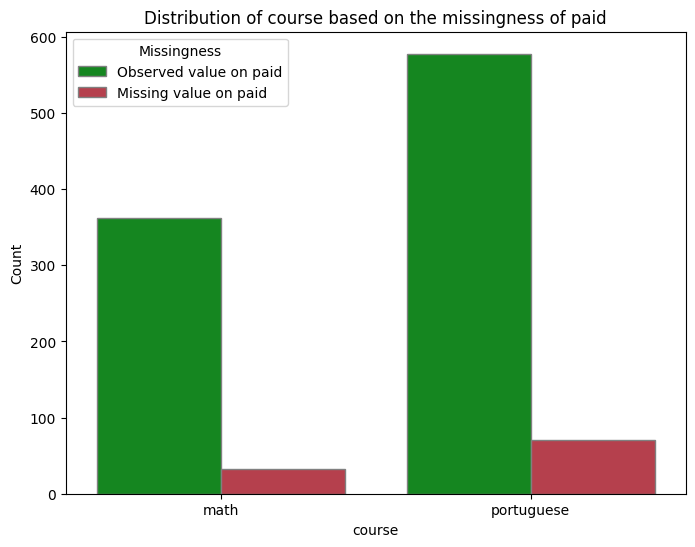

In [25]:
observable_features_paid = ["reason", "higher", "course"]

_ = mv.plot_missingness_distribution(missing_df[observable_features_paid + ["paid"]], missing_col="paid", display_plot=True)

From the resulting plots, it can be observed that the number of missing values in `paid` is generally proportional to the number of observations within each category. For example, the `course` variable shows a similar missingness rate for both `math` and `portuguese`, with approximately 10% of the values missing in each group.

The only variable that noticeably deviates from this pattern is the `reputation` category within the `reason` column. This category presents a missingness rate of approximately 15%, whereas the other categories show missingness rates between 7% and 9%. The next code cell quantifies this difference more precisely. Of course the difference is not too substantial and, by itself, does not give sufficient evidence that there is indeed an dependency between `reason` and the missingness of `paid`.

In [26]:
table = pd.crosstab(missing_df["reason"], missing_df["paid"].isna(), normalize="index")

print(table)

paid           False     True 
reason                        
course      0.906977  0.093023
home        0.934109  0.065891
other       0.916667  0.083333
reputation  0.846774  0.153226


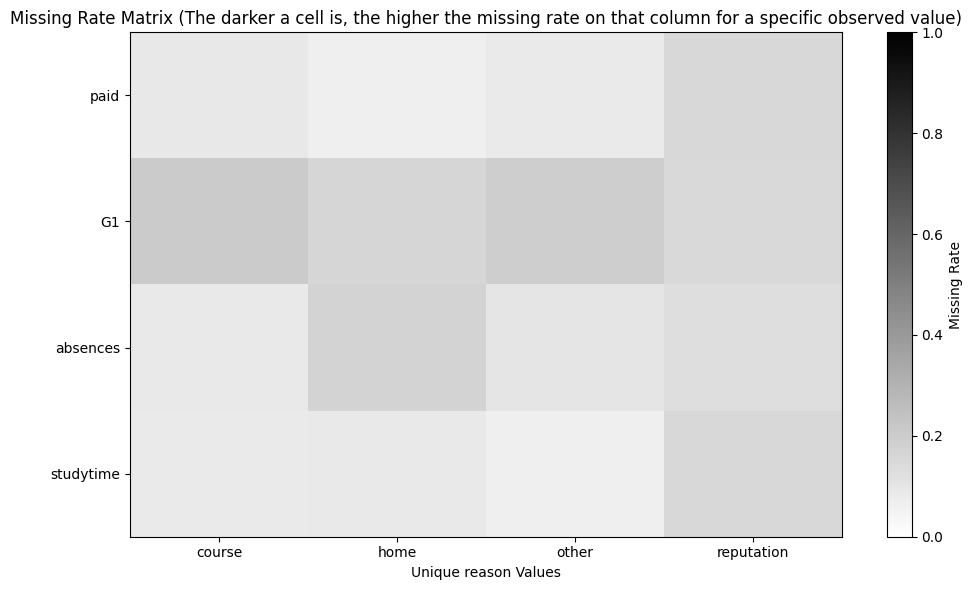

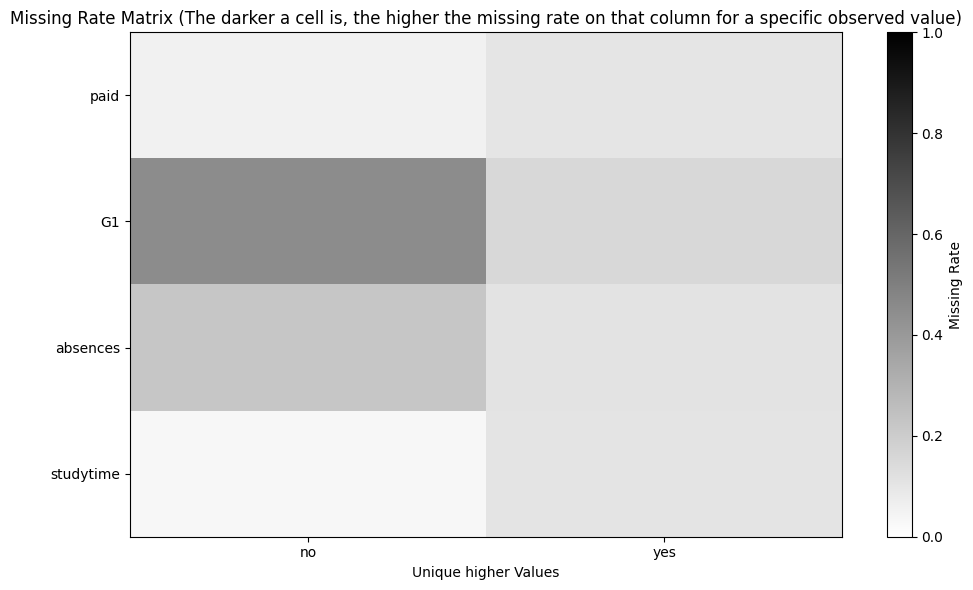

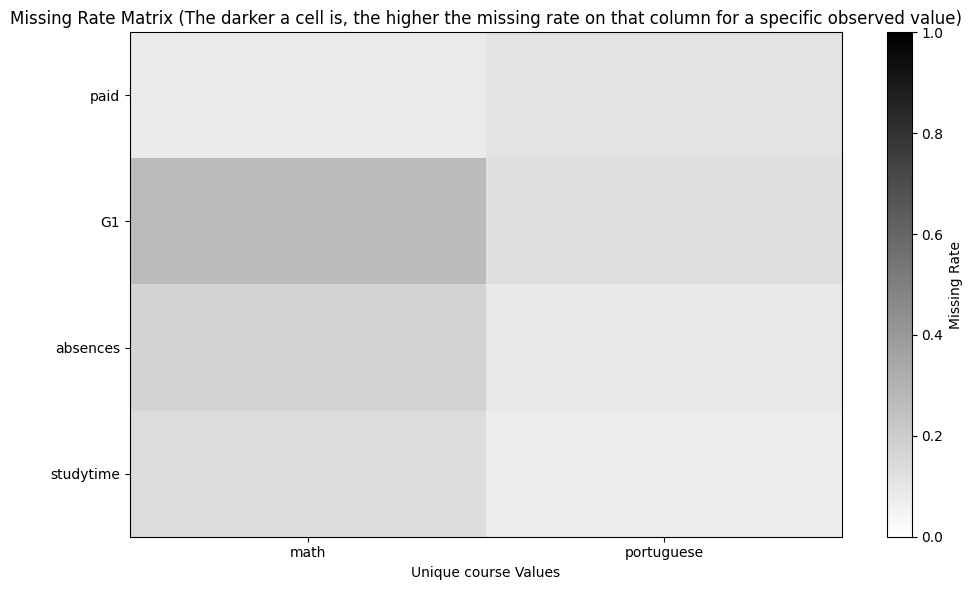

In [27]:
missing_columns = ["paid", "G1", "absences", "studytime"]

observable_features_paid = ["reason", "higher", "course"]

for observable_column in observable_features_paid:
    mv.missing_rate_matrix(missing_df[missing_columns + [observable_column]], column_name=observable_column, display_plot=True)

Once again, the missing column `paid` does not exhibit a strong relation between its missingness and the observable columns. Conversely, `G1` has a stronger missing rate between different categories compared to `paid`.

Imputation of the `paid` column can also be made to find if the proportions of the column are preserved almost exactly after the imputation.

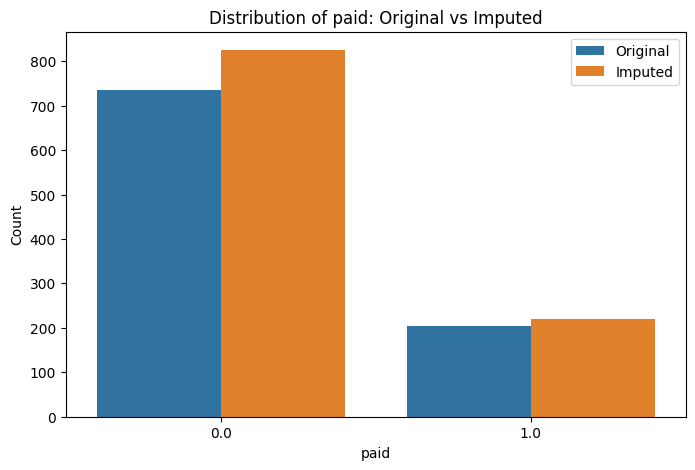

In [28]:
from mechanism_viewer import ColType

_ = mv.plot_imputation_distribution( missing_df_numeric[["paid", "reason", "higher", "course"]], "paid", missing_col_type=ColType.BINARY, display_plot=True)

The distribution of ``paid`` before and after imputation remains pratically the same. In other words, the proportions are preserved almost exactly after imputing the missing values using the defined observable features.

A pairwise test can be done as well to evaluate `paid` as an variable with MCAR missing mechanism. Since `G1` is know to have a missing pattern resembling MAR mechanism, it can be used to compare the `paid` pattern.

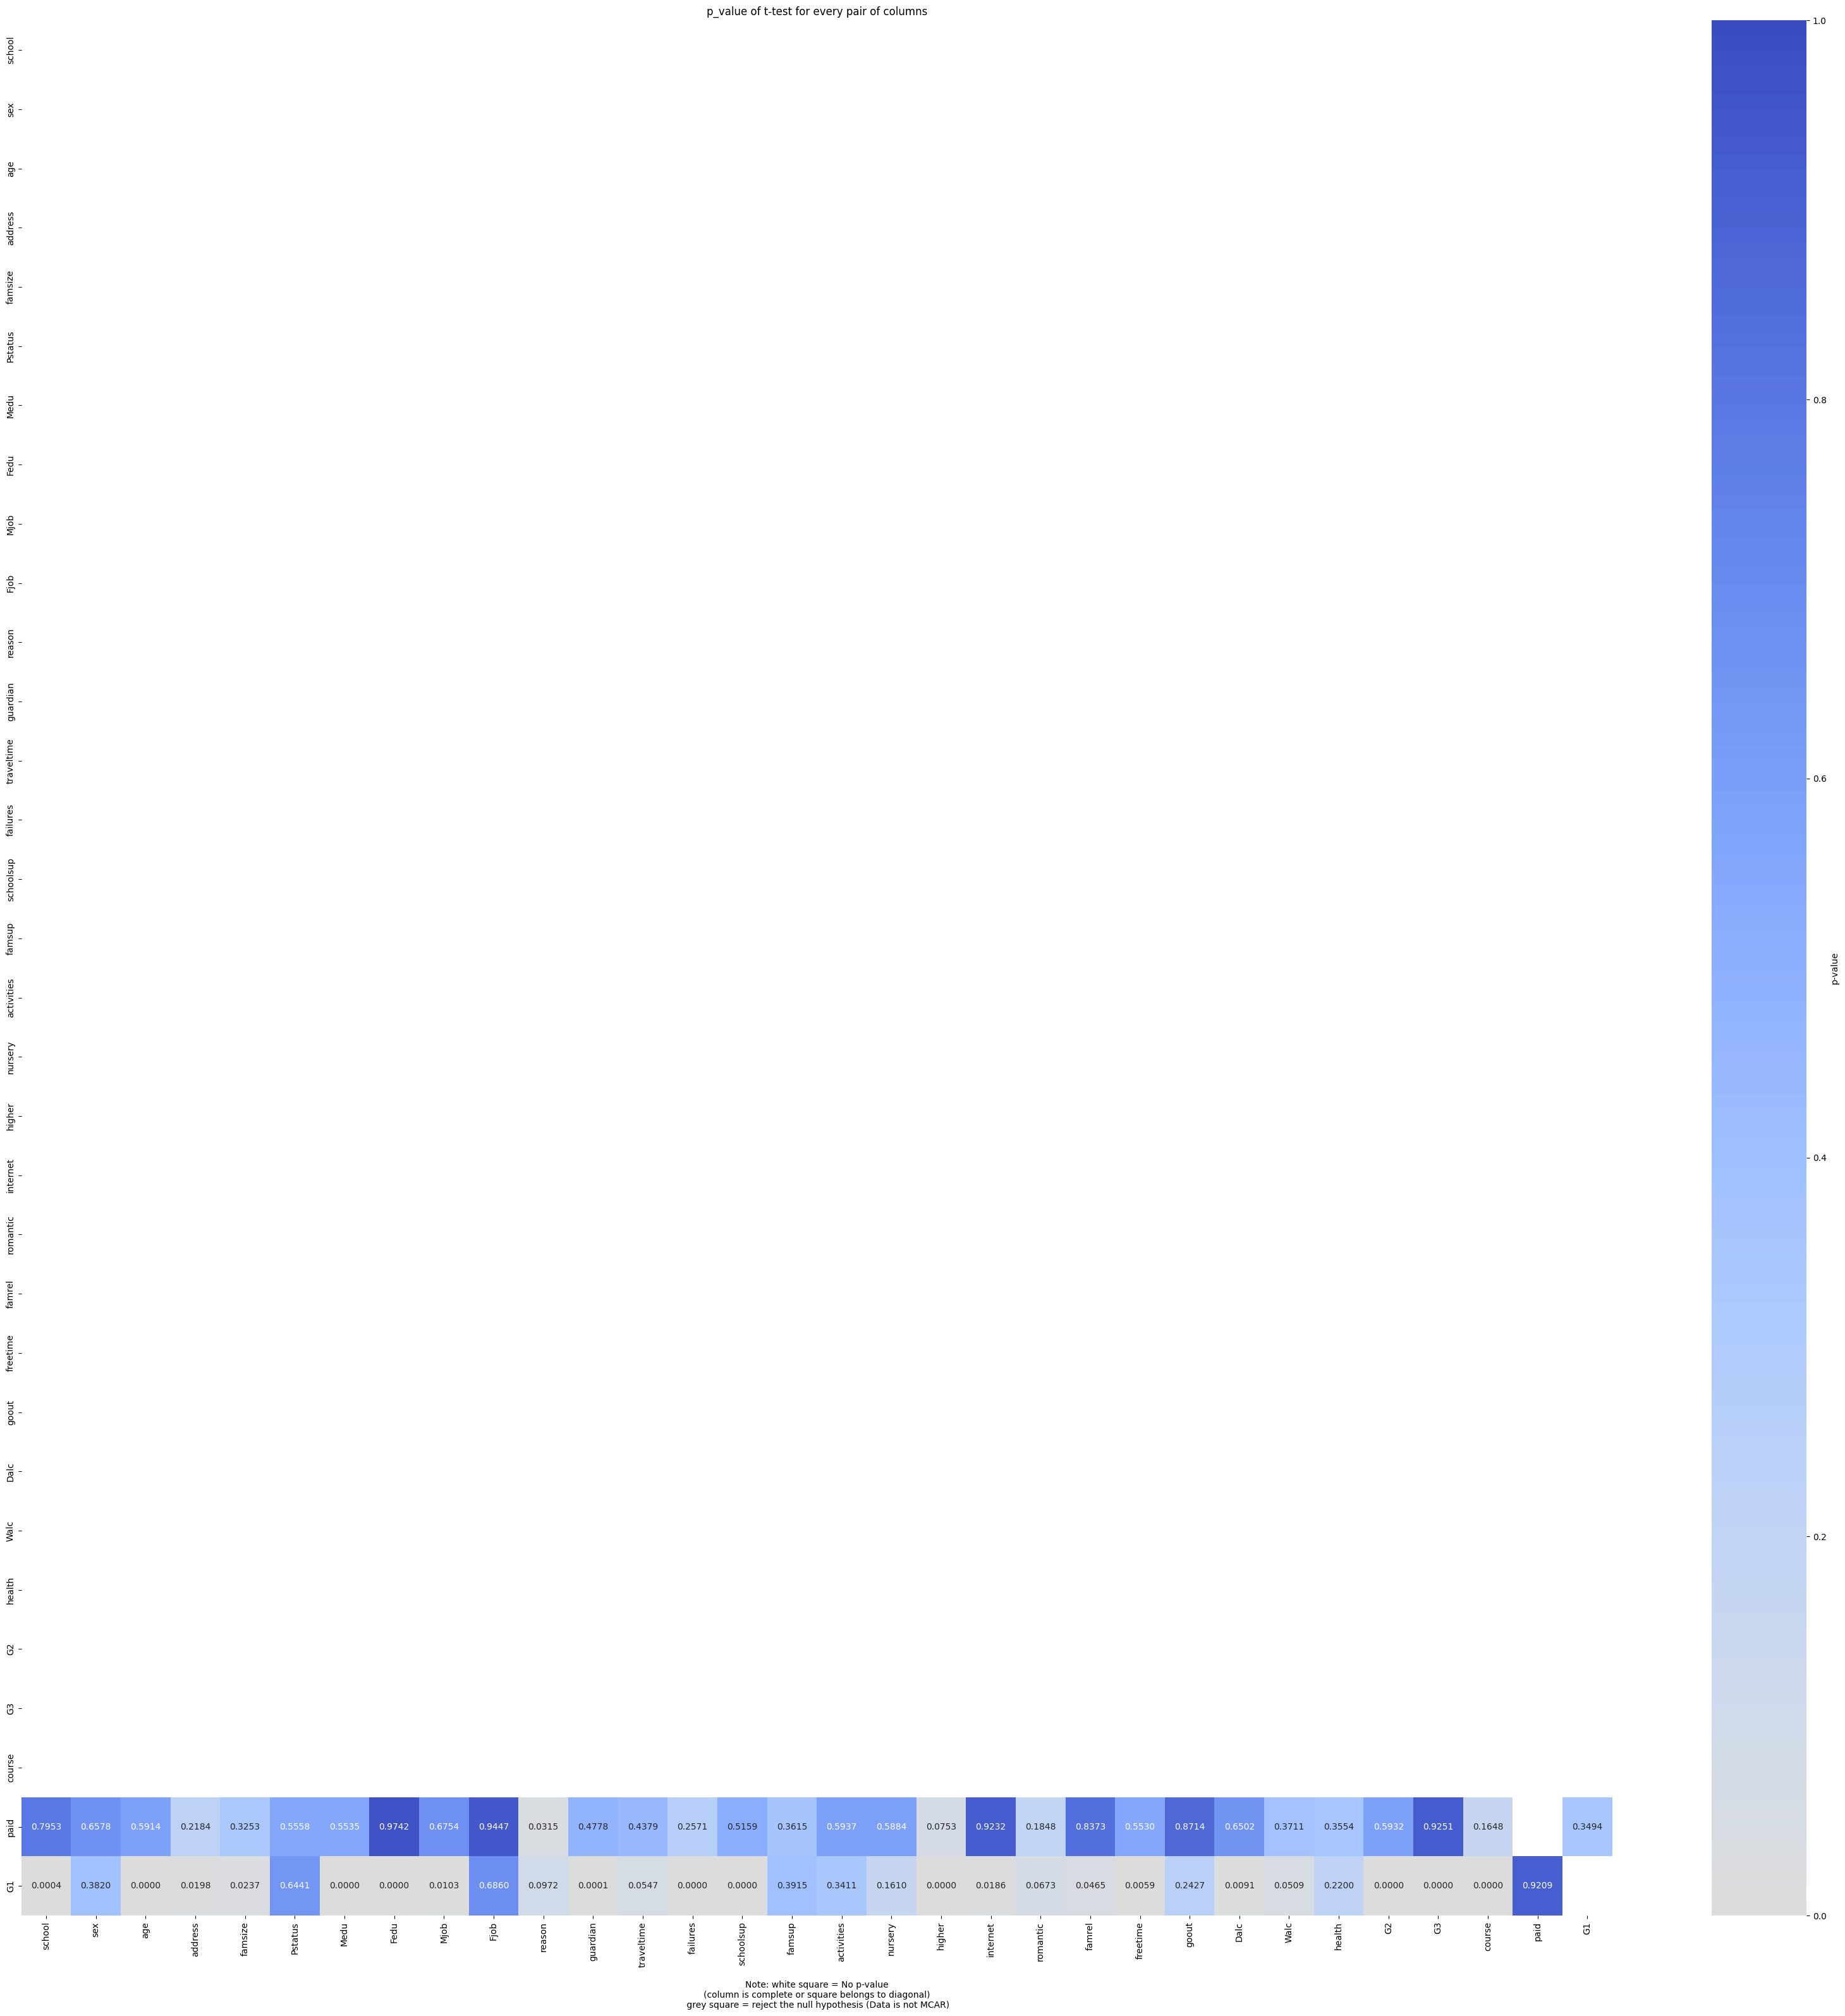

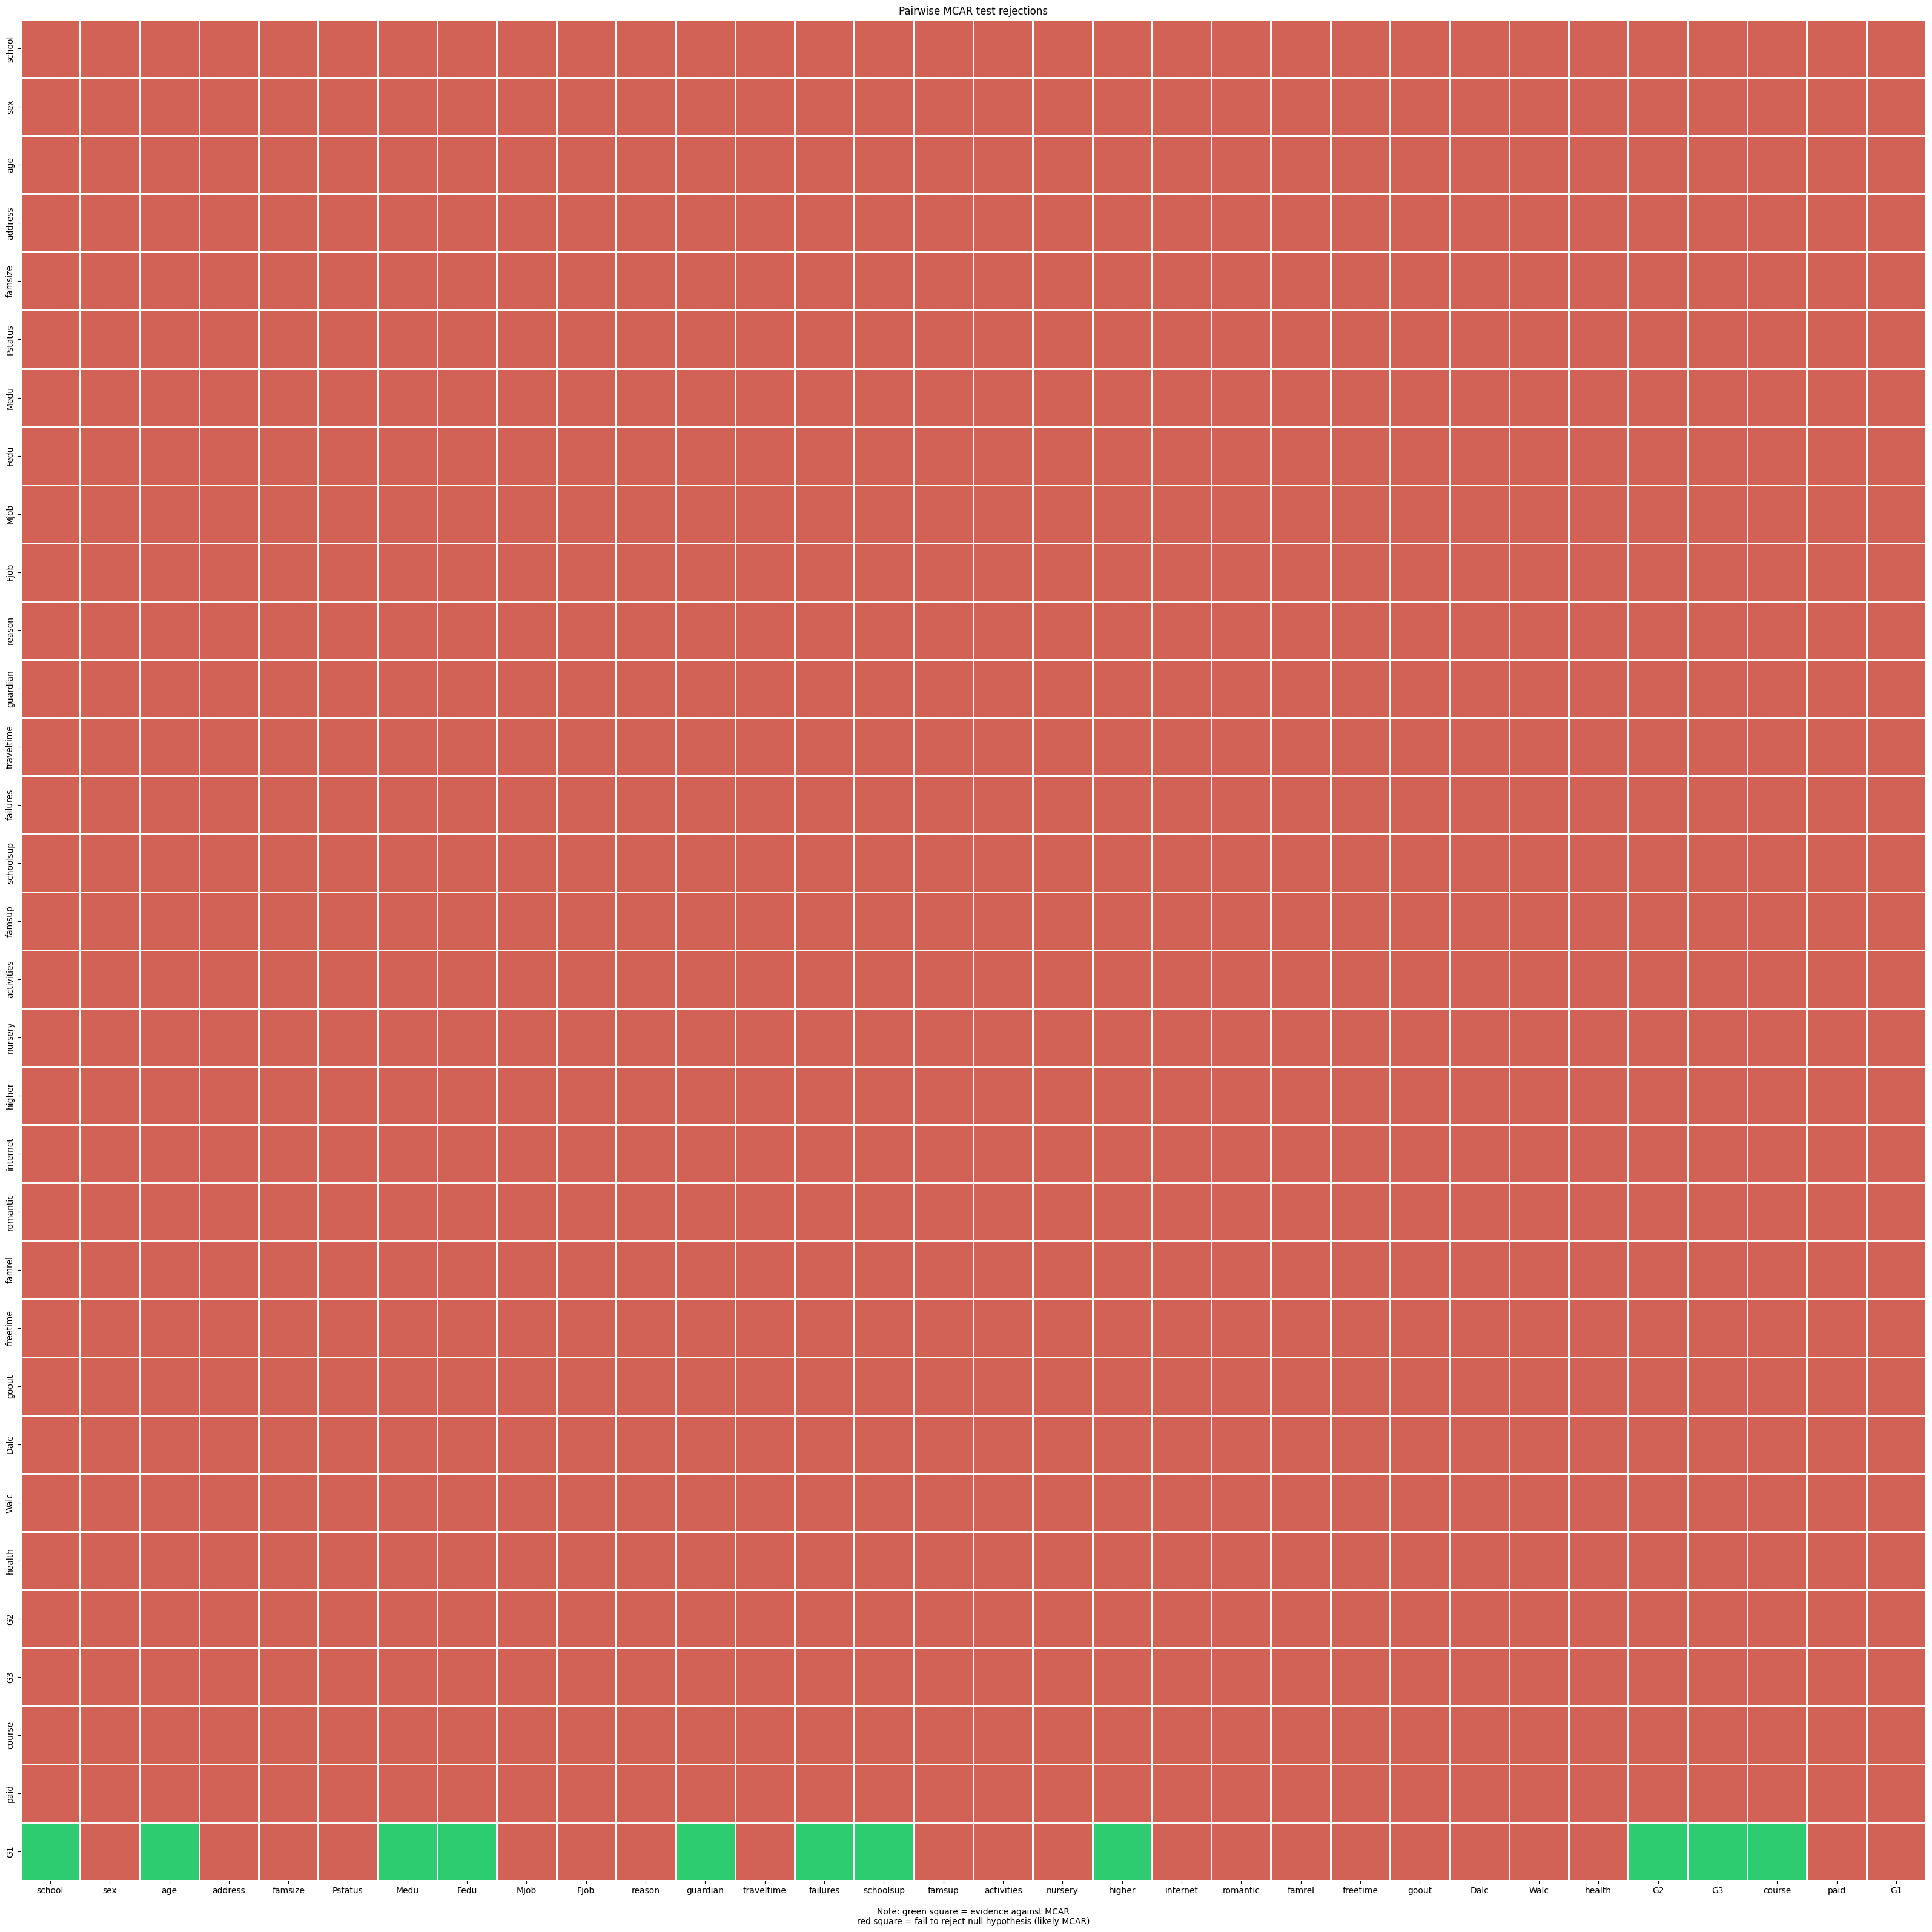

(<Figure size 3200x3200 with 2 Axes>,
 <Axes: title={'center': 'p_value of t-test for every pair of columns'}, xlabel='Note: white square = No p-value\n(column is complete or square belongs to diagonal)\n grey square = reject the null hypothesis (Data is not MCAR)'>,
 <Figure size 3200x3200 with 1 Axes>,
 <Axes: title={'center': 'Pairwise MCAR test rejections'}, xlabel='Note: green square = evidence against MCAR\nred square = fail to reject null hypothesis (likely MCAR)'>)

In [29]:
p_values = mv.little_mcar_pairwise(missing_df_numeric.drop(["studytime", "absences"], axis=1)) 

mv.plot_mcar_pairwise(p_values, alpha = 0.005,display_plot=True)

When put under a strict alpha, `paid` showed no missingness relationship with other observable features, which is the opposite from `G1`.

Together with the previous statistical tests and dependency visualizations, this provides additional evidence that the missingness of ``paid`` is broadly consistent with an MCAR mechanism.

### 15. Missing mechanism of `studytime`

From the `studytime` column, the information obtained previously is the following:

- Has a low missing rate, similar to `paid`.
- Its missingness has weak correlations with the values of the columns observed in the dataset
- The test cannot identify with certainty that the column has missingness predictable with observed variables.

Therefore, inside this section, more tests will be done to find more clues about its missing mechanism.

First, it will be uncovered if there is any dependency that occurs in the observable values of `studytime` but not if the missingness is compared, and vice-versa. The next image was taken from previous sections, showing the correlation of the columns when `studytime` missingness: the heatmap has weak correlations, but not as weak as `paid`.

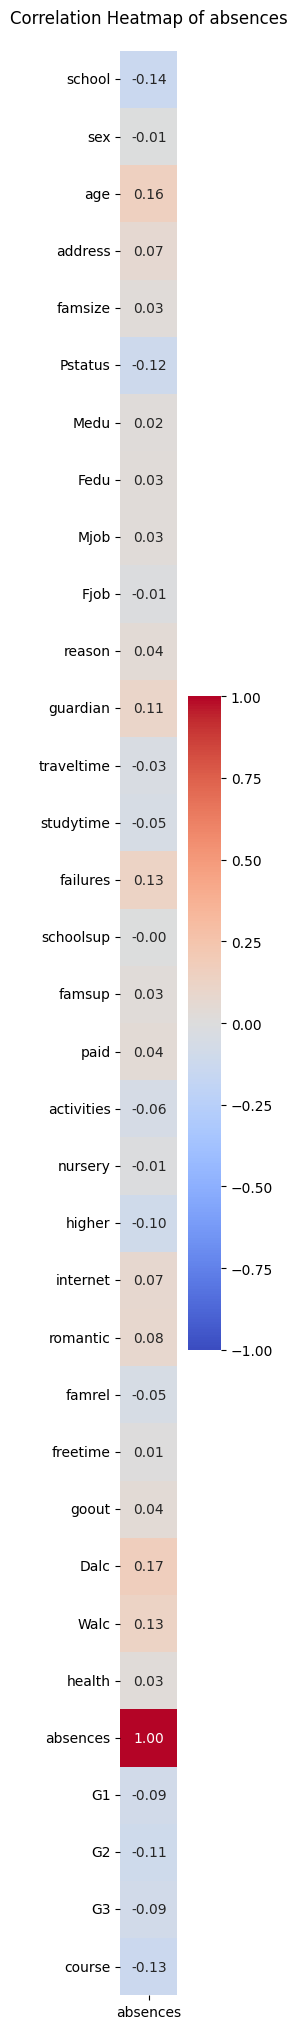

Now, the following heatmap will exhibit the value correlation between the observed values of `studytime` and other columns.

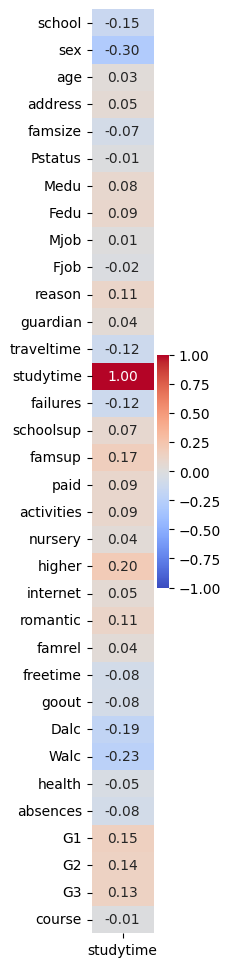

In [30]:
studytime_corr = missing_df_numeric.corr()

plt.figure(figsize=(1, 12))

_ = sns.heatmap(studytime_corr[["studytime"]], annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

This heatmap clearly indicates that `sex`, `Dalc`, `Walc`, `higher` and other features have higher absolute correlation with the values of `studytime` compared with the actual missingness of `studytime`. Therefore, the missingness pattern of `studytime` does not follow the observed value dependency of the observed features. In particular, since the missingness does not seem to have any strong relation with the other features, then it is conclusive that the pattern of `studytime` does not depend in other features. As a result, the missingness mechanism is not likely MAR, which is similar to the evidence provided by other tests.

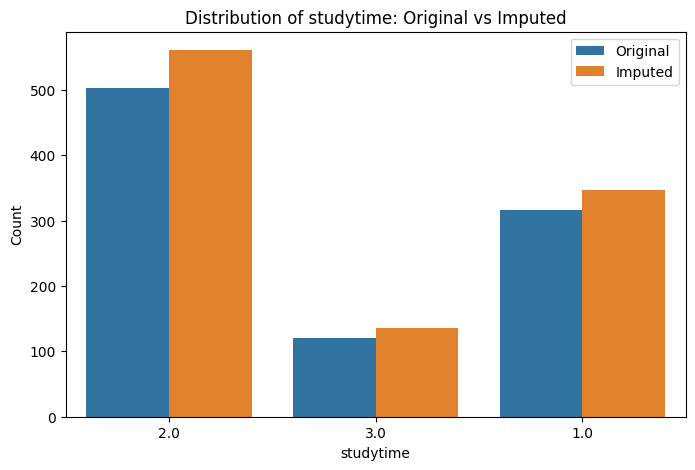

In [31]:
_ = mv.plot_imputation_distribution( missing_df_numeric, "studytime", missing_col_type=ColType.DISC_CATEGORICAL , display_plot=True)

The imputation plot also does not reveal additional information related to the pattern of the missingness: all categories have proportional increase, giving a similar distribution compared with distribution where missing values are present. Thus, the missingness is likely not MAR.

Nevertheless, due to insufficient evidence, it is not possible to identify the true pattern of the feature, especially because the variable has small number of categories, high distribution imbalance, and low amount of missing values. This impedes from considering other visualization plots that may have helped to find the mechanism otherwise.

### 16. Missing mechanism of `absences`

For ``absences`` it is a somewhat different process, since has missingness correlations that are not as weak as the last two missing columns. For instance, `Dalc` and `age` have correlation between 0.17 and 0.16, among many columns with correlation between 0.12 and 0.14.

Despite that, the column did not show much evidence for possible model MAR prediction.

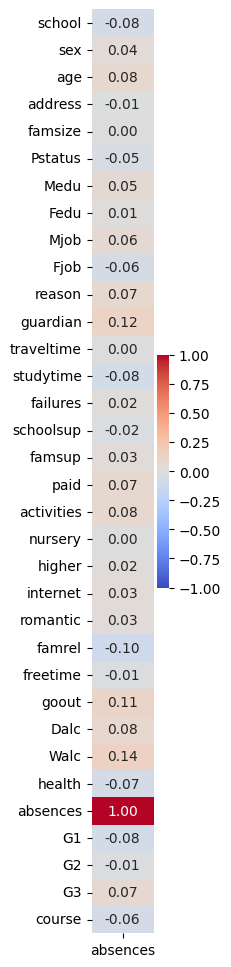

In [32]:
absences_corr = missing_df_numeric.corr()

plt.figure(figsize=(1, 12))

_ = sns.heatmap(absences_corr[["absences"]], annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

The value correlation between the columns and the values of the observed `absences` demonstrates that normally there is weak correlation betwen `absences` and the other features. However, when comparing with the missingness predictor, correlation increases slighlty. This usually happens when the underlying mechanism is MAR. In the other hand, knowing that missing column did not show an high MAR prediction score, more test need to be done before reaching a conclusion.

An imputation of the missing column will be done to caught any changes to the distribution.

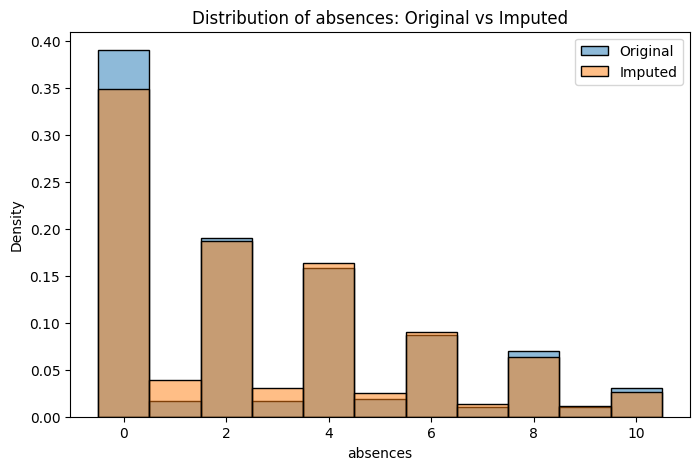

In [33]:
_, _, imputed_absences_full = mv.plot_imputation_distribution( missing_df_numeric, "absences", missing_col_type=ColType.DISCRETE , display_plot=True)

By observing the bars, the major peaks remain, but the peak at 0 becomes noticeably smaller. In addition, values between the peaks become more common. This means that after the imputation, the distribution became smoother.

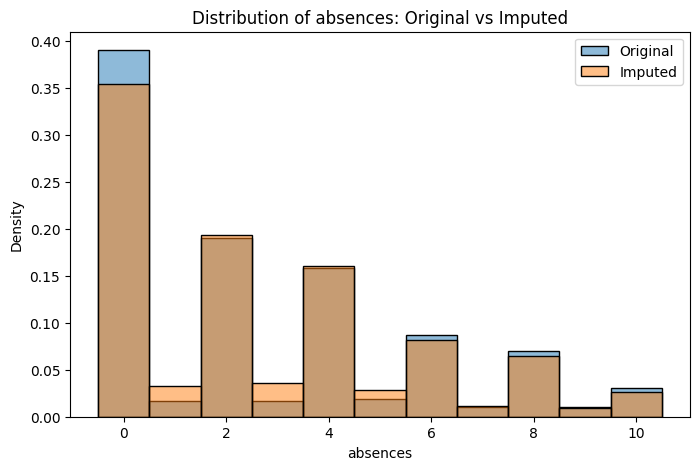

In [34]:
cols = missing_df_numeric.columns.tolist()
cols.remove("age")
cols.remove("Dalc")
cols.remove("school")
cols.remove("Pstatus")
cols.remove("failures")
cols.remove("course")
cols.remove("Walc")

_, _, imputed_absences_rmv = mv.plot_imputation_distribution( missing_df_numeric[cols], "absences", missing_col_type=ColType.DISCRETE , display_plot=True)

When removing most of the features that could generate the missingness pattern of `absences`, and then start the imputation process once again, it is noteable that the distribution does not change considerable compared to plot that uses all features for imputation.

Therefore the removal of features did not change the way the missing values of `absences` change after imputation.

To confirm this test, the difference of imputed values between each imputed dataset is displayed. 

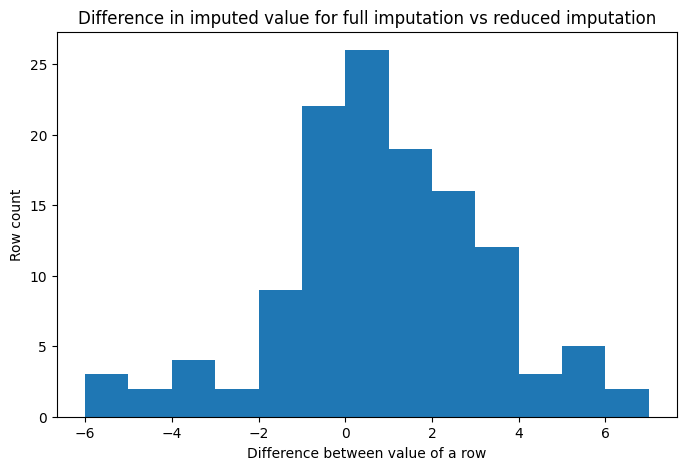

In [35]:
mask = missing_df_numeric["absences"].isna()

row_difference = (imputed_absences_full.loc[mask, "absences"]- imputed_absences_rmv.loc[mask, "absences"])

plt.figure(figsize=(8,5))
plt.hist(row_difference, bins=13)
plt.xlabel("Difference between value of a row")
plt.ylabel("Row count")
plt.title("Difference in imputed value for full imputation vs reduced imputation")
plt.show()

Most imputed rows do not change much of their imputed value between the two processes. Most of them are in between -2 and 4 difference in values. The difference is not substational to consider that the features impacted the imputation of the missing column. As a consequence, it is hard to beleive that this missing feature has MAR as its missing-data mechanism.

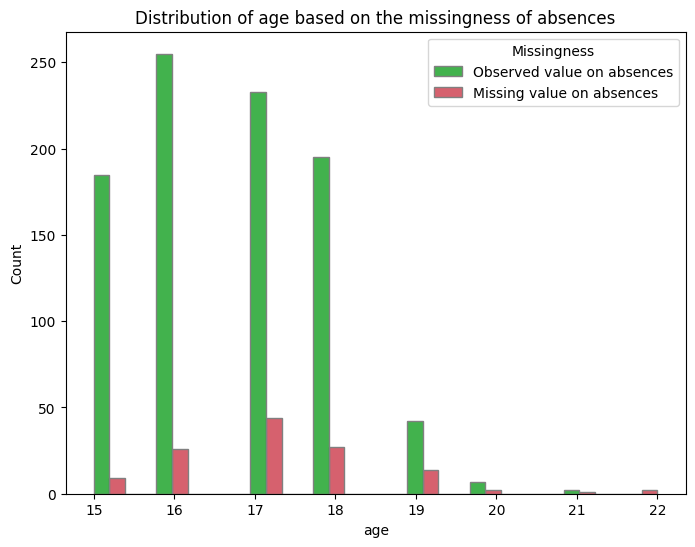

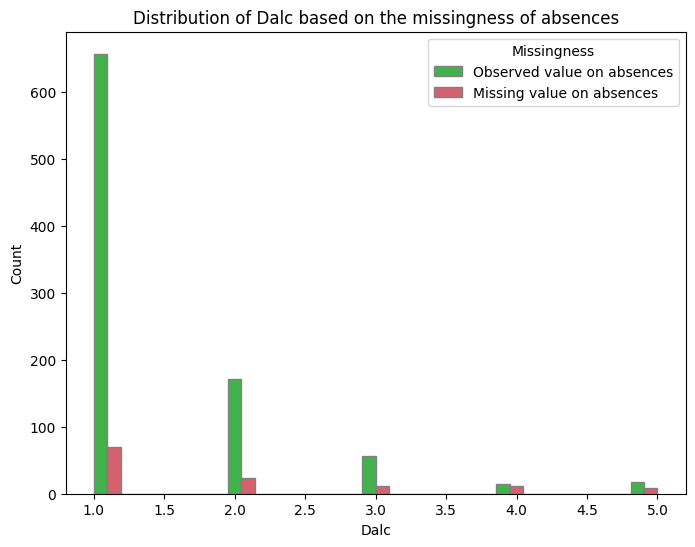

In [36]:
observable_features_absences = ["age", "Dalc"]

_ = mv.plot_missingness_distribution(missing_df[observable_features_absences + ["absences"]], missing_col="absences", display_plot=True)

Nevertheless, the plots show that missingness of `absences` does not decrease proportionally according the the size of the bars. When the `age` is higher or when the `Dalc` is higher, the missing rate is much higher.

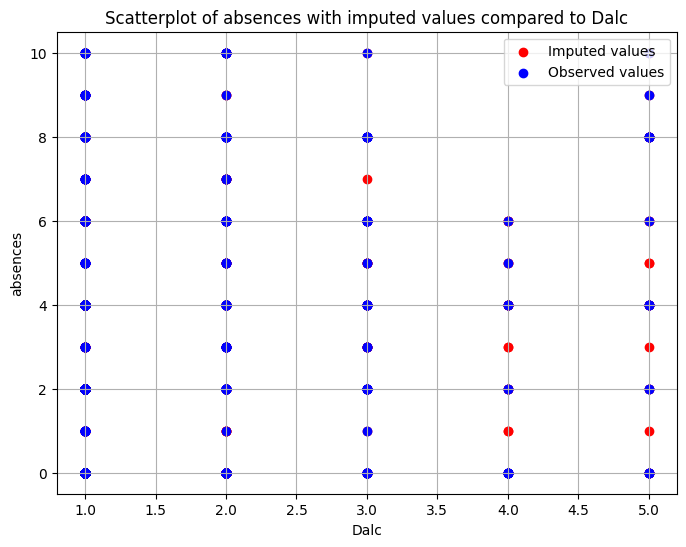

In [37]:
_ = mv.scatter_imputation_comparison( missing_df_numeric, "Dalc", "absences", missing_col_type=ColType.DISCRETE , display_plot=True)

Furthermore, it is clear that when `Dalc` is higher, there are not as many rows with `absences`. But, the imputation using all the features does not fill all the blank spaces, it only predicts low `absences`.

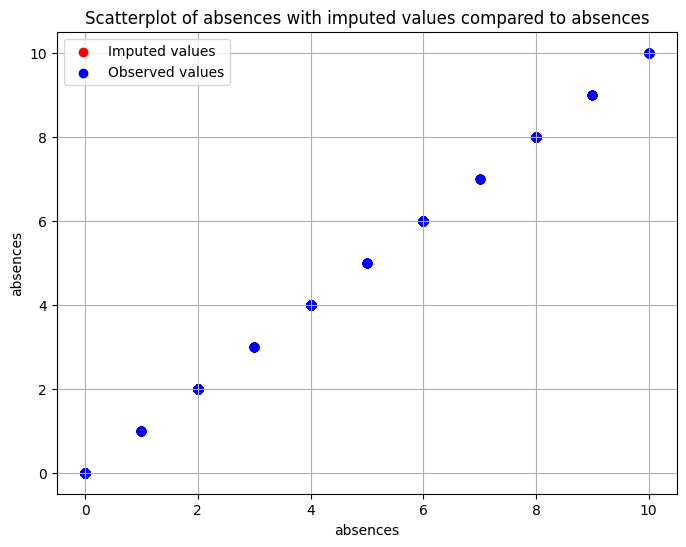

In [38]:
_ = mv.scatter_imputation_comparison( missing_df_numeric, "absences", "absences", missing_col_type=ColType.DISCRETE , display_plot=True)

When only using the same feature to compare the imputed values, clearly it is an impossible task to confirm whether it is a MCAR or a MNAR pattern.

In conclusion, although some insights were discovered, no pattern can be confirmed due to insufficient results.

### 17. Summary of missingness pattern identification

After analysing the encoded dataset with missing-data mechanisms applied to selected columns, these are the conclusions that can be draw.

- `paid` is likely MCAR. Its missingness does not appear to be strongly affected by, correlated with, or associated with the observable features.

- `G1` has multiple evidences connecting to a MAR mechanism. The most likely observed features that are tied to `G1` missingness are `failures` and `age`. The columns `schoolsup` and `higher` are similar in results, and do not play the main role for the missingness dependency, focusing only on giving support. Both `Medu` and `Fedu` show a weak support for the missing pattern. Lastly, `course` is the weakest feature supporting the missingness pattern of `G1`

- `absences` and `studytime` show similar yet oposite missingness patterns. While, the first feature has increased missingness correlation compared to correlation between the values of observed rows, `studytime` shows weaker correlation. However, both features did not give sufficient evidence for any missing-data mechanism, mostly due to their low missing rate, type of feature and low cardinality. 

### 18. Final conclusion

First of all, the missingness mechanisms of `paid` and `G1` were successfully found, although some additional features were included to give support for the missingness of `G1`. Unfortunately, the missing columns `absences` and `studytime` had their missingness mechanism undiscovered. Naturally, MNAR columns are trickier to prove, but also due to the reasons explained above, they were harder to even prove a strong likeness to MNAR. If given an distribution of these features withouth any missing values, it would definetly help the discovery of the irregular distributions. But since this testing was done without the original data, to closely resemble real life cases, the evidences were not enough.